# TheLook E-Commerce: Mid-Point Check de ETL y Feature Engineering

## Pregunta de negocio

¿Qué características iniciales de un cliente están asociadas con que realice una segunda compra durante los 90 días posteriores a su primera orden?

## Unidad de análisis

Cada fila de la Feature Table representa un cliente identificado mediante `user_id`.

## Label

`label_repeat_purchase_90d`

- `1`: el cliente realizó al menos otra orden distinta dentro de los 90 días posteriores a su primera orden.
- `0`: el cliente no realizó otra orden durante ese periodo.

La predicción se plantea al momento de la primera orden. Las features utilizan únicamente información conocida hasta ese instante. Para evitar censura temporal, solo se incluyen clientes cuya primera orden ocurrió al menos 90 días antes de la fecha máxima disponible.

## 0. Instalación y autenticación

In [ ]:
%pip install -q google-cloud-bigquery db-dtypes

In [2]:
PROJECT_ID = "ia-2026-506700"  # <--- Cada alumno pone su ID de proyecto

from google.cloud import bigquery
import pandas as pd
import requests
import io
import zipfile
### No le gustan las mayúsculas al cliente
client = bigquery.Client(project=PROJECT_ID.lower())

from google.cloud import bigquery
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

project_id = "refined-lotus-505300-g4"
dataset_name = "thelook_feature_engineering"
feature_table_name = "user_repeat_purchase_features"
feature_table_id = f"{project_id}.{dataset_name}.{feature_table_name}"
location = "US"

client = bigquery.Client(project=project_id, location=location)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = ["#FF6B35", "#264653", "#2A9D8F", "#E9C46A", "#E76F51", "#457B9D"]
plt.rcParams.update({"figure.figsize": (10, 5.5), "axes.titleweight": "bold"})

print(f"Proyecto: {project_id}")
print(f"Feature Table: {feature_table_id}")

DefaultCredentialsError: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.

## 1. Estimación del procesamiento

El `dry_run` permite estimar los bytes que procesaría BigQuery sin ejecutar la consulta.

In [ ]:
def estimate_query_bytes(sql):
    job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    dry_job = client.query(sql, job_config=job_config)
    bytes_processed = dry_job.total_bytes_processed
    print(f"Bytes estimados: {bytes_processed:,}")
    print(f"GB estimados: {bytes_processed / 1e9:.4f}")
    return bytes_processed

## 2. Exploración de las fuentes

In [ ]:
sql_tables = """
SELECT
    table_name,
    table_type
FROM `bigquery-public-data.thelook_ecommerce`.INFORMATION_SCHEMA.TABLES
WHERE table_type = 'BASE TABLE'
ORDER BY table_name
"""

estimate_query_bytes(sql_tables)
df_tables = client.query(sql_tables).to_dataframe()
display(df_tables)

Bytes estimados: 10,485,760
GB estimados: 0.0105


,table_name,table_type
0,distribution_centers,BASE TABLE
1,events,BASE TABLE
2,inventory_items,BASE TABLE
3,order_items,BASE TABLE
4,orders,BASE TABLE
5,products,BASE TABLE
6,users,BASE TABLE


,table_name,total_rows
1,events,2429601
2,inventory_items,490883
3,order_items,181758
4,orders,125191
6,users,100000
5,products,29120
0,distribution_centers,10


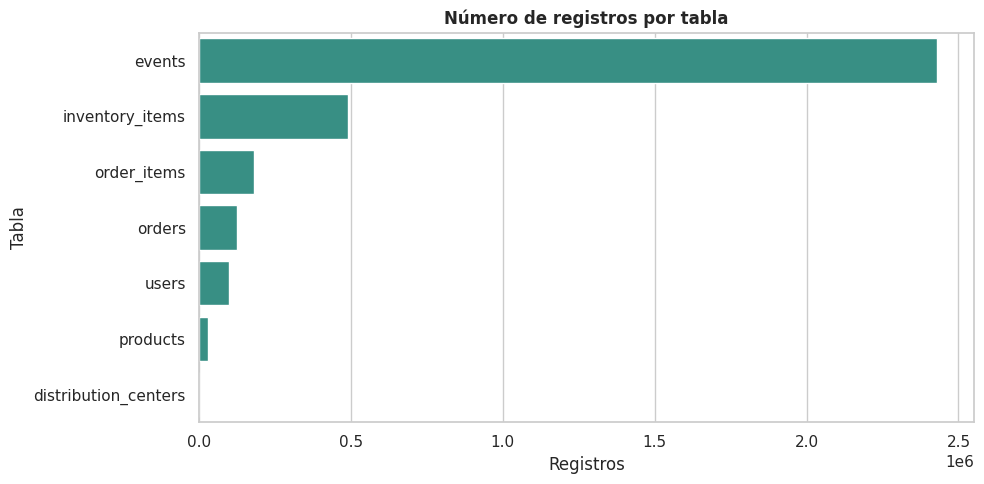

In [ ]:
tables = df_tables["table_name"].tolist()
row_counts = []

for table in tables:
    sql_count = f"""
    SELECT COUNT(*) AS total_rows
    FROM `bigquery-public-data.thelook_ecommerce.{table}`
    """
    total_rows = client.query(sql_count).to_dataframe().loc[0, "total_rows"]
    row_counts.append({"table_name": table, "total_rows": total_rows})

row_counts_df = pd.DataFrame(row_counts).sort_values("total_rows", ascending=False)
display(row_counts_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=row_counts_df, x="total_rows", y="table_name", color=COLORS[2])
plt.title("Número de registros por tabla")
plt.xlabel("Registros")
plt.ylabel("Tabla")
plt.tight_layout()
plt.show()

## 3. Exploración del esquema relevante

La Feature Table utiliza `users`, `events`, `orders` y `order_items`. Se revisan sus columnas para documentar las fuentes y las llaves utilizadas.

In [ ]:
sql_relevant_columns = """
SELECT
    table_name,
    column_name,
    data_type,
    is_nullable,
    ordinal_position
FROM `bigquery-public-data.thelook_ecommerce`.INFORMATION_SCHEMA.COLUMNS
WHERE table_name IN ('users', 'events', 'orders', 'order_items')
ORDER BY table_name, ordinal_position
"""

df_relevant_columns = client.query(sql_relevant_columns).to_dataframe()
display(df_relevant_columns)

,table_name,column_name,data_type,is_nullable,ordinal_position
0,events,id,INT64,YES,1
1,events,user_id,INT64,YES,2
2,events,sequence_number,INT64,YES,3
3,events,session_id,STRING,YES,4
4,events,created_at,TIMESTAMP,YES,5
5,events,ip_address,STRING,YES,6
6,events,city,STRING,YES,7
7,events,state,STRING,YES,8
8,events,postal_code,STRING,YES,9
9,events,browser,STRING,YES,10


## 4. EDA inicial de eventos y órdenes

Los eventos describen navegación, mientras que `orders` permite distinguir órdenes realmente diferentes. El label de recompra se construye con `COUNT(DISTINCT order_id)`, no con eventos `purchase`, porque una orden con varios artículos puede producir múltiples registros relacionados con la compra.

In [ ]:
sql_event_types = """
SELECT
    LOWER(event_type) AS event_type,
    COUNT(*) AS total_events,
    COUNT(DISTINCT session_id) AS sessions,
    COUNT(DISTINCT user_id) AS identified_users,
    SAFE_DIVIDE(COUNT(*), SUM(COUNT(*)) OVER()) AS event_share
FROM `bigquery-public-data.thelook_ecommerce.events`
GROUP BY event_type
ORDER BY total_events DESC
"""

df_event_types = client.query(sql_event_types).to_dataframe()
display(df_event_types.style.format({
    "total_events": "{:,.0f}",
    "sessions": "{:,.0f}",
    "identified_users": "{:,.0f}",
    "event_share": "{:.1%}"
}))

,event_type,total_events,sessions,identified_users,event_share
0,product,"844,886","681,758","79,913",34.8%
1,department,"595,134","432,006","79,913",24.5%
2,cart,"595,087","431,959","79,913",24.5%
3,purchase,"181,758","181,758","79,913",7.5%
4,cancel,"125,316","125,316",0,5.2%
5,home,"87,420","87,420","62,873",3.6%


,orders,users,user_share
0,1,"49,652",62.1%
1,2,"20,222",25.3%
2,3,"5,061",6.3%
3,4,"4,978",6.2%


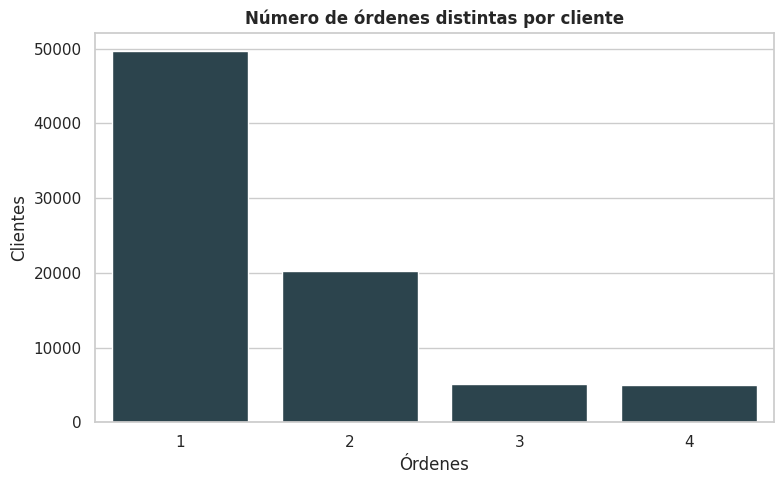

In [ ]:
sql_order_profile = """
WITH orders_per_user AS (
    SELECT
        user_id,
        COUNT(DISTINCT order_id) AS orders,
        MIN(created_at) AS first_order_at,
        MAX(created_at) AS last_order_at
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE user_id IS NOT NULL
      AND created_at IS NOT NULL
    GROUP BY user_id
)
SELECT
    orders,
    COUNT(*) AS users,
    SAFE_DIVIDE(COUNT(*), SUM(COUNT(*)) OVER()) AS user_share
FROM orders_per_user
GROUP BY orders
ORDER BY orders
"""

df_orders_per_user = client.query(sql_order_profile).to_dataframe()
display(df_orders_per_user.style.format({"users": "{:,.0f}", "user_share": "{:.1%}"}))

plt.figure(figsize=(8, 5))
sns.barplot(data=df_orders_per_user, x="orders", y="users", color=COLORS[1])
plt.title("Número de órdenes distintas por cliente")
plt.xlabel("Órdenes")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

Bytes estimados: 4,796,015
GB estimados: 0.0048


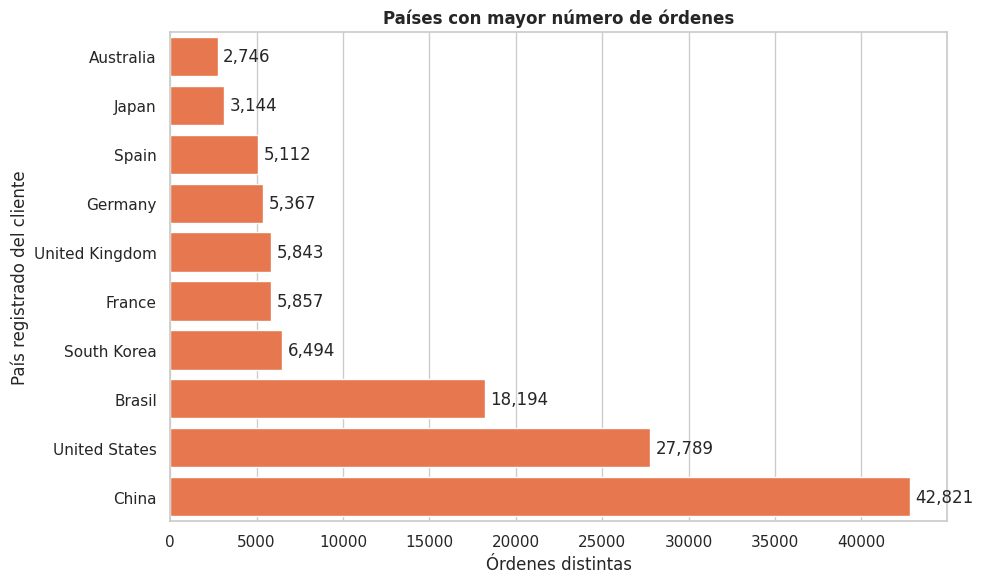

In [ ]:
sql_orders_by_country = """
WITH country_orders AS (
    SELECT
        COALESCE(users.country, 'Unknown') AS country,
        COUNT(DISTINCT orders.order_id) AS total_orders,
        COUNT(DISTINCT orders.user_id) AS purchasing_customers
    FROM `bigquery-public-data.thelook_ecommerce.orders` AS orders
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS users
        ON orders.user_id = users.id
    WHERE orders.order_id IS NOT NULL
      AND orders.created_at IS NOT NULL
    GROUP BY country
)

SELECT
    country,
    total_orders,
    purchasing_customers,
    SAFE_DIVIDE(total_orders, purchasing_customers) AS orders_per_customer,
    SAFE_DIVIDE(
        total_orders,
        SUM(total_orders) OVER()
    ) AS order_share
FROM country_orders
ORDER BY total_orders DESC
"""

estimate_query_bytes(sql_orders_by_country)

df_orders_by_country = client.query(
    sql_orders_by_country
).to_dataframe()

country_top = (
    df_orders_by_country
    .head(10)
    .sort_values("total_orders")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=country_top,
    x="total_orders",
    y="country",
    color=COLORS[0]
)

ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in country_top["total_orders"]],
    padding=4
)

plt.title("Países con mayor número de órdenes")
plt.xlabel("Órdenes distintas")
plt.ylabel("País registrado del cliente")
plt.tight_layout()
plt.show()

Bytes estimados: 8,273,869
GB estimados: 0.0083


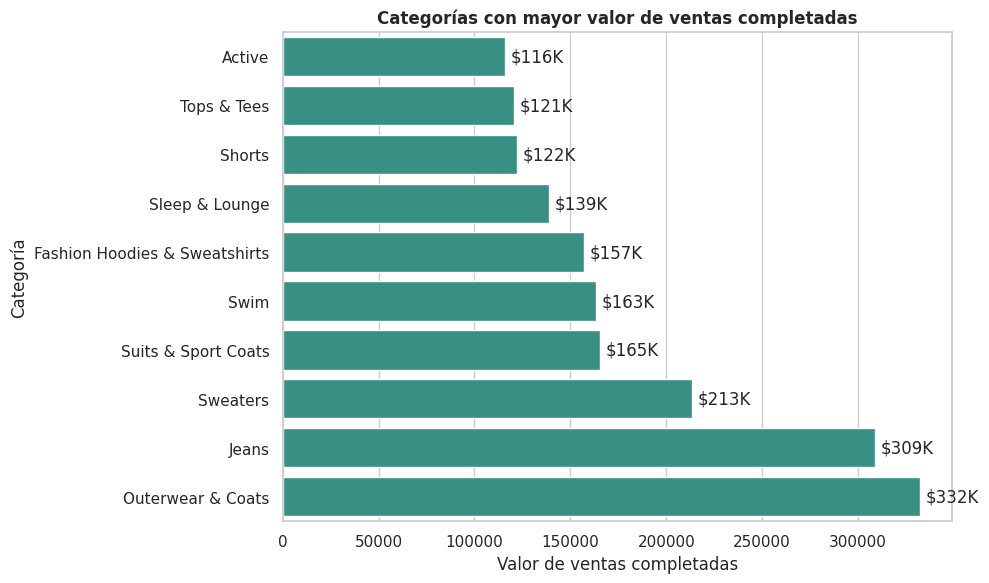

In [ ]:
sql_sales_by_category = """
SELECT
    COALESCE(products.category, 'Unknown') AS category,
    COUNT(DISTINCT order_items.order_id) AS completed_orders,
    COUNT(order_items.id) AS completed_items,
    SUM(order_items.sale_price) AS completed_revenue,
    SAFE_DIVIDE(
        SUM(order_items.sale_price),
        COUNT(DISTINCT order_items.order_id)
    ) AS revenue_per_order
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS order_items
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` AS products
    ON order_items.product_id = products.id
WHERE LOWER(order_items.status) = 'complete'
GROUP BY category
ORDER BY completed_revenue DESC
"""

estimate_query_bytes(sql_sales_by_category)

df_sales_by_category = client.query(
    sql_sales_by_category
).to_dataframe()
category_top = (
    df_sales_by_category
    .head(10)
    .sort_values("completed_revenue")
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_top,
    x="completed_revenue",
    y="category",
    color=COLORS[2]
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"${value / 1_000:,.0f}K"
        for value in category_top["completed_revenue"]
    ],
    padding=4
)

plt.title("Categorías con mayor valor de ventas completadas")
plt.xlabel("Valor de ventas completadas")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Bytes estimados: 3,004,584
GB estimados: 0.0030


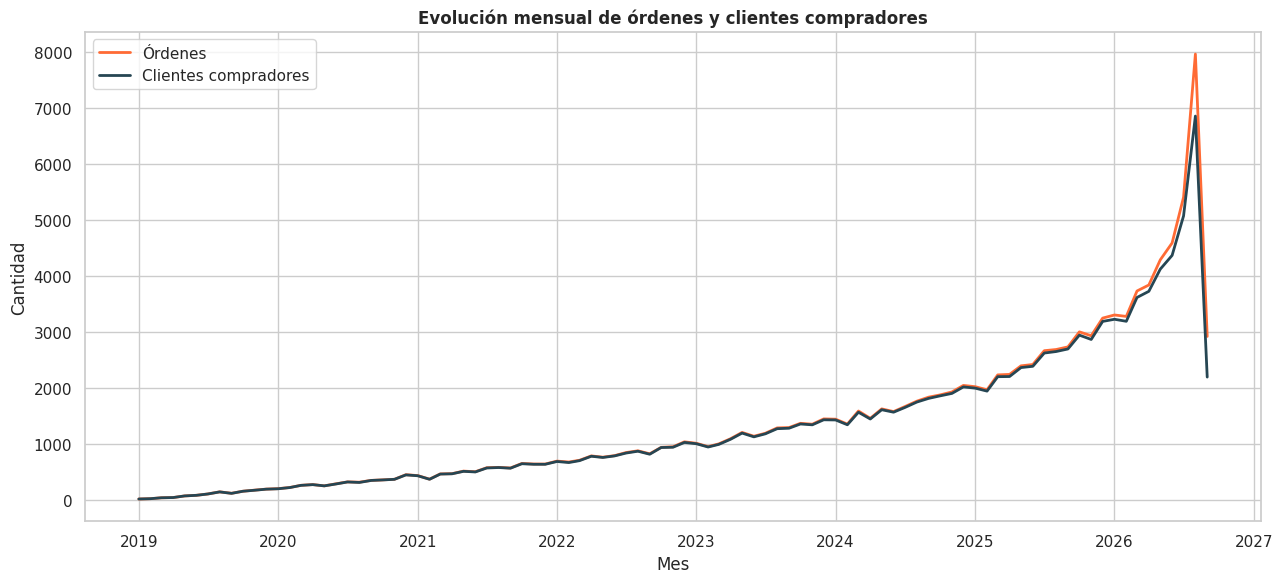

In [ ]:
sql_monthly_orders = """
SELECT
    DATE_TRUNC(DATE(created_at), MONTH) AS order_month,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT user_id) AS purchasing_customers
FROM `bigquery-public-data.thelook_ecommerce.orders`
WHERE order_id IS NOT NULL
  AND user_id IS NOT NULL
  AND created_at IS NOT NULL
GROUP BY order_month
ORDER BY order_month
"""

estimate_query_bytes(sql_monthly_orders)

df_monthly_orders = client.query(
    sql_monthly_orders
).to_dataframe()

df_monthly_orders["order_month"] = pd.to_datetime(
    df_monthly_orders["order_month"]
)
monthly_long = df_monthly_orders.melt(
    id_vars="order_month",
    value_vars=["total_orders", "purchasing_customers"],
    var_name="metric",
    value_name="count"
)

monthly_long["metric"] = monthly_long["metric"].map({
    "total_orders": "Órdenes",
    "purchasing_customers": "Clientes compradores"
})

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=monthly_long,
    x="order_month",
    y="count",
    hue="metric",
    palette=[COLORS[0], COLORS[1]],
    linewidth=2
)

plt.title("Evolución mensual de órdenes y clientes compradores")
plt.xlabel("Mes")
plt.ylabel("Cantidad")
plt.legend(title="")
plt.tight_layout()
plt.show()

Bytes estimados: 3,286,500
GB estimados: 0.0033


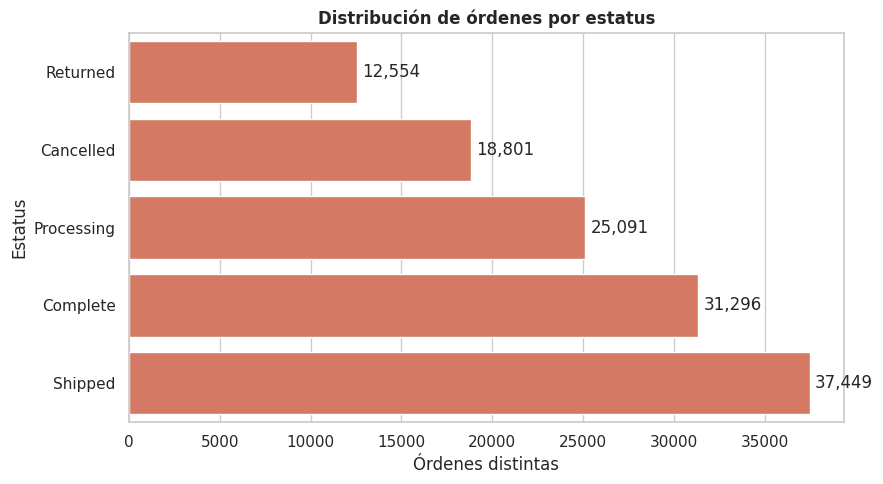

In [ ]:
sql_order_status = """
WITH status_summary AS (
    SELECT
        COALESCE(status, 'Unknown') AS order_status,
        COUNT(DISTINCT order_id) AS total_orders,
        COUNT(DISTINCT user_id) AS customers
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE order_id IS NOT NULL
    GROUP BY order_status
)

SELECT
    order_status,
    total_orders,
    customers,
    SAFE_DIVIDE(
        total_orders,
        SUM(total_orders) OVER()
    ) AS order_share
FROM status_summary
ORDER BY total_orders DESC
"""

estimate_query_bytes(sql_order_status)

df_order_status = client.query(
    sql_order_status
).to_dataframe()

status_plot = df_order_status.sort_values("total_orders")

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=status_plot,
    x="total_orders",
    y="order_status",
    color=COLORS[4]
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{value:,.0f}"
        for value in status_plot["total_orders"]
    ],
    padding=4
)

plt.title("Distribución de órdenes por estatus")
plt.xlabel("Órdenes distintas")
plt.ylabel("Estatus")
plt.tight_layout()
plt.show()

In [ ]:
top_country_row = df_orders_by_country.loc[df_orders_by_country['total_orders'].idxmax()]
top_country_name = top_country_row['country']
top_country_share = top_country_row['order_share']

top_category_row = df_sales_by_category.loc[df_sales_by_category['completed_revenue'].idxmax()]
top_category_name = top_category_row['category']
top_category_revenue = top_category_row['completed_revenue']

peak_month_row = df_monthly_orders.loc[df_monthly_orders['total_orders'].idxmax()]
peak_month_orders = peak_month_row['total_orders']

completed_share_value = df_order_status.loc[df_order_status['order_status'] == 'Complete', 'order_share'].iloc[0]

display(Markdown(f"""
### Hallazgos del EDA global

- TheLook registra **{df_orders_by_country['total_orders'].sum():,.0f} órdenes distintas**.
- **{top_country_name}** concentra el mayor volumen, con
  **{top_country_share:.2%} de las órdenes**.
- **{top_category_name}** es la categoría con mayor valor de ventas
  completadas, con **${top_category_revenue:,.2f}**.
- El mes con mayor volumen registró **{peak_month_orders:,.0f} órdenes**.
- Las órdenes completadas representan **{completed_share_value:.2%} del total**.

Estos resultados proporcionan el contexto general del negocio. La construcción
posterior del label y de las features utiliza una cohorte temporal específica para
evitar fuga de información.
"""))


### Hallazgos del EDA global

- TheLook registra **125,191 órdenes distintas**.
- **China** concentra el mayor volumen, con
  **34.20% de las órdenes**.
- **Outerwear & Coats** es la categoría con mayor valor de ventas
  completadas, con **$332,280.14**.
- El mes con mayor volumen registró **7,970 órdenes**.
- Las órdenes completadas representan **25.00% del total**.

Estos resultados proporcionan el contexto general del negocio. La construcción
posterior del label y de las features utiliza una cohorte temporal específica para
evitar fuga de información.


## 5. Diseño temporal del label y las features

El momento de predicción es la primera orden del cliente.

- Features: perfil, primera orden y eventos conocidos hasta `first_order_at`.
- Label: existencia de otra orden distinta durante los 90 días siguientes.
- Elegibilidad: primera orden al menos 90 días antes de la fecha máxima del dataset.

Esta separación evita utilizar actividad posterior a la primera orden como predictor de la recompra.

In [ ]:
sql_cohort_preview = """
WITH order_horizon AS (
    SELECT MAX(created_at) AS max_order_at
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE created_at IS NOT NULL
),
first_order AS (
    SELECT
        user_id,
        ARRAY_AGG(
            STRUCT(order_id, created_at, num_of_item)
            ORDER BY created_at, order_id
            LIMIT 1
        )[OFFSET(0)] AS first_order
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE user_id IS NOT NULL
      AND created_at IS NOT NULL
    GROUP BY user_id
)
SELECT
    COUNT(*) AS customers_with_first_order,
    COUNTIF(
        first_order.first_order.created_at <= TIMESTAMP_SUB(max_order_at, INTERVAL 90 DAY)
    ) AS eligible_customers,
    MAX(max_order_at) AS max_order_at
FROM first_order
CROSS JOIN order_horizon
"""

df_cohort_preview = client.query(sql_cohort_preview).to_dataframe()
display(df_cohort_preview)

,customers_with_first_order,eligible_customers,max_order_at
0,79913,69393,2026-09-03 00:42:38.894216+00:00


,window_days,eligible_customers,repeat_customers,repeat_rate
0,30,"74,462","2,661",3.57%
1,60,"71,833","4,432",6.17%
2,90,"69,393","5,750",8.29%
3,180,"63,119","8,471",13.42%


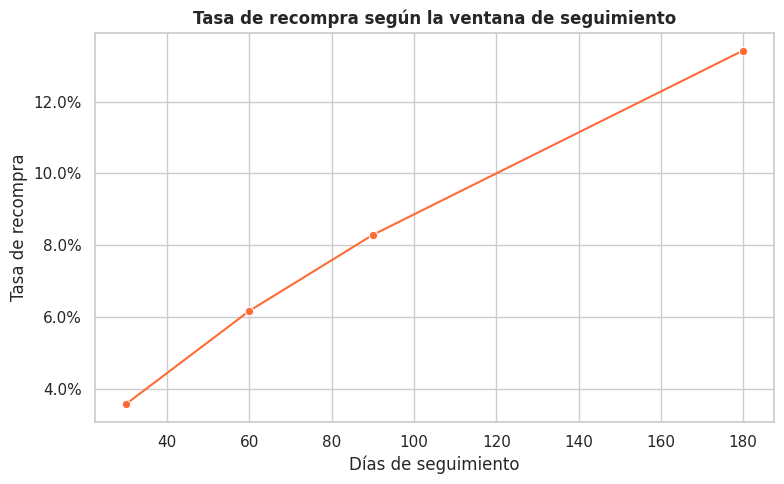

In [ ]:
sql_window_comparison = """
WITH order_horizon AS (
    SELECT MAX(created_at) AS max_order_at
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE created_at IS NOT NULL
),
first_order AS (
    SELECT
        user_id,
        ARRAY_AGG(
            STRUCT(order_id, created_at)
            ORDER BY created_at, order_id
            LIMIT 1
        )[OFFSET(0)] AS first_order
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE user_id IS NOT NULL
      AND created_at IS NOT NULL
    GROUP BY user_id
),
windows AS (
    SELECT 30 AS window_days
    UNION ALL SELECT 60
    UNION ALL SELECT 90
    UNION ALL SELECT 180
)
SELECT
    windows.window_days,
    COUNT(DISTINCT IF(
        first_order.first_order.created_at <= TIMESTAMP_SUB(
            horizon.max_order_at,
            INTERVAL windows.window_days DAY
        ),
        first_order.user_id,
        NULL
    )) AS eligible_customers,
    COUNT(DISTINCT IF(
        first_order.first_order.created_at <= TIMESTAMP_SUB(
            horizon.max_order_at,
            INTERVAL windows.window_days DAY
        )
        AND orders.order_id != first_order.first_order.order_id
        AND orders.created_at > first_order.first_order.created_at
        AND orders.created_at <= TIMESTAMP_ADD(
            first_order.first_order.created_at,
            INTERVAL windows.window_days DAY
        ),
        first_order.user_id,
        NULL
    )) AS repeat_customers,
    SAFE_DIVIDE(
        COUNT(DISTINCT IF(
            first_order.first_order.created_at <= TIMESTAMP_SUB(
                horizon.max_order_at,
                INTERVAL windows.window_days DAY
            )
            AND orders.order_id != first_order.first_order.order_id
            AND orders.created_at > first_order.first_order.created_at
            AND orders.created_at <= TIMESTAMP_ADD(
                first_order.first_order.created_at,
                INTERVAL windows.window_days DAY
            ),
            first_order.user_id,
            NULL
        )),
        COUNT(DISTINCT IF(
            first_order.first_order.created_at <= TIMESTAMP_SUB(
                horizon.max_order_at,
                INTERVAL windows.window_days DAY
            ),
            first_order.user_id,
            NULL
        ))
    ) AS repeat_rate
FROM first_order
CROSS JOIN order_horizon AS horizon
CROSS JOIN windows
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS orders
    ON first_order.user_id = orders.user_id
GROUP BY windows.window_days
ORDER BY windows.window_days
"""

df_window_comparison = client.query(sql_window_comparison).to_dataframe()
display(df_window_comparison.style.format({
    "eligible_customers": "{:,.0f}",
    "repeat_customers": "{:,.0f}",
    "repeat_rate": "{:.2%}"
}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_window_comparison, x="window_days", y="repeat_rate", marker="o", color=COLORS[0], ax=ax)
ax.set_title("Tasa de recompra según la ventana de seguimiento")
ax.set_xlabel("Días de seguimiento")
ax.set_ylabel("Tasa de recompra")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.tight_layout()
plt.show()

Primero encontramos a quienes compraron. Después conservamos a quienes podemos observar durante 30,60,90 y 180 días. Finalmente identificamos quiénes volvieron a comprar dentro de ese periodo. Al comparar ventanas de 30, 60, 90 y 180 se seleccionaron 90 porque conserva 69,548 clientes elegibles y permite identificar 5,786 recompradores, equivalentes a una tasa de 8.32%. Esta ventana ofrece un equilibrio entre disponer de suficientes casos positivos y mantener un horizonte de recompra temprano y comercialmente accionable.

## 6. Persistencia de la Feature Table

Crear una tabla analítica permanente en el proyecto propio.

In [ ]:
dataset_id = f"{project_id}.{dataset_name}"
dataset = bigquery.Dataset(dataset_id)
dataset.location = location
client.create_dataset(dataset, exists_ok=True)
print(f"Dataset disponible: {dataset_id}")

Dataset disponible: refined-lotus-505300-g4.thelook_feature_engineering


In [ ]:
sql_create_feature_table = f"""
CREATE OR REPLACE TABLE `{feature_table_id}` AS

WITH order_horizon AS (
    SELECT MAX(created_at) AS max_order_at
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE created_at IS NOT NULL
),

first_order AS (
    SELECT
        user_id,
        ARRAY_AGG(
            STRUCT(order_id, created_at, num_of_item)
            ORDER BY created_at, order_id
            LIMIT 1
        )[OFFSET(0)] AS first_order
    FROM `bigquery-public-data.thelook_ecommerce.orders`
    WHERE user_id IS NOT NULL
      AND created_at IS NOT NULL
    GROUP BY user_id
),

eligible_users AS (
    SELECT
        fo.user_id,
        fo.first_order.order_id AS first_order_id,
        fo.first_order.created_at AS first_order_at,
        fo.first_order.num_of_item AS first_order_items
    FROM first_order AS fo
    CROSS JOIN order_horizon AS horizon
    WHERE fo.first_order.created_at <= TIMESTAMP_SUB(horizon.max_order_at, INTERVAL 90 DAY)
),

repeat_label AS (
    SELECT
        eligible.user_id,
        eligible.first_order_id,
        eligible.first_order_at,
        eligible.first_order_items,
        IF(
            COUNT(DISTINCT IF(
                orders.order_id != eligible.first_order_id
                AND orders.created_at > eligible.first_order_at
                AND orders.created_at <= TIMESTAMP_ADD(eligible.first_order_at, INTERVAL 90 DAY),
                orders.order_id,
                NULL
            )) > 0,
            1,
            0
        ) AS label_repeat_purchase_90d
    FROM eligible_users AS eligible
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS orders
        ON eligible.user_id = orders.user_id
    GROUP BY
        eligible.user_id,
        eligible.first_order_id,
        eligible.first_order_at,
        eligible.first_order_items
),

first_order_value AS (
    SELECT
        eligible.user_id,
        COALESCE(SUM(items.sale_price), 0) AS first_order_value,
        COUNT(items.id) AS first_order_lines
    FROM eligible_users AS eligible
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.order_items` AS items
        ON eligible.first_order_id = items.order_id
    GROUP BY eligible.user_id
),

pre_purchase_behavior AS (
    SELECT
        eligible.user_id,
        COUNTIF(LOWER(events.event_type) NOT IN ('purchase', 'cancel')) AS pre_purchase_events,
        COUNT(DISTINCT IF(
            LOWER(events.event_type) NOT IN ('purchase', 'cancel'),
            events.session_id,
            NULL
        )) AS pre_purchase_sessions,
        COUNT(DISTINCT IF(
            LOWER(events.event_type) NOT IN ('purchase', 'cancel'),
            DATE(events.created_at),
            NULL
        )) AS pre_purchase_active_days,
        COUNTIF(LOWER(events.event_type) = 'home') AS home_events,
        COUNTIF(LOWER(events.event_type) = 'department') AS department_events,
        COUNTIF(LOWER(events.event_type) = 'product') AS product_events,
        COUNTIF(LOWER(events.event_type) = 'cart') AS cart_events,
        COUNT(DISTINCT IF(
            LOWER(events.event_type) NOT IN ('purchase', 'cancel'),
            events.uri,
            NULL
        )) AS distinct_pages,
        MIN(IF(
            LOWER(events.event_type) NOT IN ('purchase', 'cancel'),
            events.created_at,
            NULL
        )) AS first_known_event_at
    FROM eligible_users AS eligible
    LEFT JOIN `bigquery-public-data.thelook_ecommerce.events` AS events
        ON eligible.user_id = events.user_id
       AND events.created_at <= eligible.first_order_at
    GROUP BY eligible.user_id
),

age_statistics AS (
    SELECT APPROX_QUANTILES(age, 2)[OFFSET(1)] AS median_age
    FROM `bigquery-public-data.thelook_ecommerce.users`
    WHERE age IS NOT NULL
)

SELECT
    label.user_id,
    label.first_order_id,
    label.first_order_at,
    EXTRACT(HOUR FROM label.first_order_at) AS first_order_hour,
    EXTRACT(DAYOFWEEK FROM label.first_order_at) AS first_order_day,
    COALESCE(label.first_order_items, 0) AS first_order_items,
    COALESCE(value.first_order_lines, 0) AS first_order_lines,
    COALESCE(value.first_order_value, 0) AS first_order_value,
    COALESCE(behavior.pre_purchase_events, 0) AS pre_purchase_events,
    COALESCE(behavior.pre_purchase_sessions, 0) AS pre_purchase_sessions,
    COALESCE(behavior.pre_purchase_active_days, 0) AS pre_purchase_active_days,
    COALESCE(behavior.home_events, 0) AS home_events,
    COALESCE(behavior.department_events, 0) AS department_events,
    COALESCE(behavior.product_events, 0) AS product_events,
    COALESCE(behavior.cart_events, 0) AS cart_events,
    COALESCE(behavior.distinct_pages, 0) AS distinct_pages,
    COALESCE(
        TIMESTAMP_DIFF(label.first_order_at, behavior.first_known_event_at, SECOND),
        0
    ) AS seconds_from_first_event_to_order,
    IF(behavior.first_known_event_at IS NULL, 1, 0) AS pre_purchase_history_missing,
    COALESCE(users.age, age_stats.median_age) AS age,
    IF(users.age IS NULL, 1, 0) AS age_was_missing,
    COALESCE(users.gender, 'Unknown') AS gender,
    COALESCE(users.country, 'Unknown') AS country,
    COALESCE(users.state, 'Unknown') AS state,
    COALESCE(users.city, 'Unknown') AS city,
    COALESCE(users.traffic_source, 'Unknown') AS traffic_source,
    GREATEST(
        COALESCE(TIMESTAMP_DIFF(label.first_order_at, users.created_at, DAY), 0),
        0
    ) AS days_from_signup_to_first_order,
    label.label_repeat_purchase_90d
FROM repeat_label AS label
LEFT JOIN first_order_value AS value
    USING (user_id)
LEFT JOIN pre_purchase_behavior AS behavior
    USING (user_id)
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS users
    ON label.user_id = users.id
CROSS JOIN age_statistics AS age_stats
"""

estimate_query_bytes(sql_create_feature_table)
client.query(sql_create_feature_table).result()
print(f"Feature Table creada: {feature_table_id}")

Bytes estimados: 212,256,619
GB estimados: 0.2123
Feature Table creada: refined-lotus-505300-g4.thelook_feature_engineering.user_repeat_purchase_features


## 7. Validación de la tabla persistida

Se valida el esquema, la unicidad de `user_id`, el dominio del label y el tamaño de la tabla.

In [ ]:
table = client.get_table(feature_table_id)

schema_df = pd.DataFrame([
    {"column": field.name, "type": field.field_type, "mode": field.mode}
    for field in table.schema
])

print(f"Filas persistidas: {table.num_rows:,}")
print(f"Tamaño: {table.num_bytes / (1024 ** 2):,.2f} MB")
display(schema_df)

Filas persistidas: 69,393
Tamaño: 14.53 MB


,column,type,mode
0,user_id,INTEGER,NULLABLE
1,first_order_id,INTEGER,NULLABLE
2,first_order_at,TIMESTAMP,NULLABLE
3,first_order_hour,INTEGER,NULLABLE
4,first_order_day,INTEGER,NULLABLE
5,first_order_items,INTEGER,NULLABLE
6,first_order_lines,INTEGER,NULLABLE
7,first_order_value,FLOAT,NULLABLE
8,pre_purchase_events,INTEGER,NULLABLE
9,pre_purchase_sessions,INTEGER,NULLABLE


In [ ]:
sql_validation = f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT user_id) AS unique_users,
    COUNT(*) - COUNT(DISTINCT user_id) AS duplicated_users,
    COUNTIF(label_repeat_purchase_90d NOT IN (0, 1)) AS invalid_labels,
    COUNTIF(first_order_items != first_order_lines) AS item_count_mismatches,
    MIN(first_order_at) AS min_first_order_at,
    MAX(first_order_at) AS max_first_order_at
FROM `{feature_table_id}`
"""

df_validation = client.query(sql_validation).to_dataframe()
display(df_validation)

,total_rows,unique_users,duplicated_users,invalid_labels,item_count_mismatches,min_first_order_at,max_first_order_at
0,69393,69393,0,0,0,2019-01-16 10:12:40+00:00,2026-06-05 00:01:12+00:00


In [ ]:
feature_df = client.query(f"SELECT * FROM `{feature_table_id}`").to_dataframe()
feature_df["first_order_at"] = pd.to_datetime(feature_df["first_order_at"], errors="coerce", utc=True)

print(f"Dimensión analítica: {feature_df.shape[0]:,} filas y {feature_df.shape[1]} columnas")
display(feature_df.head())

Dimensión analítica: 69,393 filas y 27 columnas


,user_id,first_order_id,first_order_at,first_order_hour,first_order_day,first_order_items,first_order_lines,first_order_value,pre_purchase_events,pre_purchase_sessions,pre_purchase_active_days,home_events,department_events,product_events,cart_events,distinct_pages,seconds_from_first_event_to_order,pre_purchase_history_missing,age,age_was_missing,gender,country,state,city,traffic_source,days_from_signup_to_first_order,label_repeat_purchase_90d
0,13252,16566,2022-07-13 15:30:06+00:00,15,4,1,1,64.00,1,1,1,1,0,0,0,1,51,0,52,0,F,Brasil,Acre,Rio Branco,Facebook,932,0
1,80181,100391,2025-07-07 04:25:38+00:00,4,2,1,1,10.00,2,1,1,1,1,0,0,2,199,0,36,0,M,Brasil,Acre,Tarauacá,Search,1278,0
2,88058,110135,2021-06-27 16:54:40+00:00,16,1,1,1,44.99,4,1,1,1,1,1,1,4,2796,0,21,0,F,Brasil,Acre,null,Search,427,0
3,77140,96679,2022-03-19 05:24:52+00:00,5,7,1,1,346.00,4,1,1,1,1,1,1,4,8365,0,42,0,M,Brasil,Acre,null,Search,175,0
4,7740,9705,2026-01-07 18:50:36+00:00,18,4,1,1,73.99,4,1,1,1,1,1,1,4,6725,0,28,0,F,Brasil,Acre,Tarauacá,Email,1329,0


## 8. Diagnóstico y tratamiento de nulos

La tabla registra la ausencia original de edad y de historial previo mediante banderas. Las categorías faltantes se convierten en `Unknown`, la edad se imputa con la mediana y los conteos sin actividad se completan con cero. Los identificadores no se imputan.

In [ ]:
null_summary = pd.DataFrame({
    "data_type": feature_df.dtypes.astype(str),
    "nulls": feature_df.isna().sum(),
    "null_pct": feature_df.isna().mean() * 100,
    "unique_values": feature_df.nunique(dropna=True)
}).sort_values(["null_pct", "unique_values"], ascending=[False, False])

display(null_summary.style.format({
    "nulls": "{:,.0f}",
    "null_pct": "{:.2f}%",
    "unique_values": "{:,.0f}"
}))

null_plot = null_summary.loc[null_summary["nulls"].gt(0)].reset_index(names="column")

if null_plot.empty:
    print("No se detectaron nulos después del tratamiento inicial.")
else:
    plt.figure(figsize=(10, max(4, len(null_plot) * 0.45)))
    sns.barplot(data=null_plot, y="column", x="null_pct", color=COLORS[4])
    plt.title("Porcentaje de nulos en la Feature Table")
    plt.xlabel("Porcentaje")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

,data_type,nulls,null_pct,unique_values
user_id,Int64,0,0.00%,"69,393"
first_order_id,Int64,0,0.00%,"69,393"
first_order_at,"datetime64[us, UTC]",0,0.00%,"69,373"
first_order_value,float64,0,0.00%,"16,507"
seconds_from_first_event_to_order,Int64,0,0.00%,"14,248"
city,object,0,0.00%,"7,382"
days_from_signup_to_first_order,Int64,0,0.00%,"2,581"
state,object,0,0.00%,227
age,Int64,0,0.00%,59
pre_purchase_events,Int64,0,0.00%,46


No se detectaron nulos después del tratamiento inicial.


## 9. Distribución del label

La distribución permite comprobar que existen las dos clases y cuantificar el desbalance. Una accuracy igual a la proporción de la clase mayoritaria se utilizará como referencia mínima, no como única métrica.

,label_repeat_purchase_90d,customers,share,outcome
0,0,"63,643",91.71%,No recompra
1,1,"5,750",8.29%,Recompra


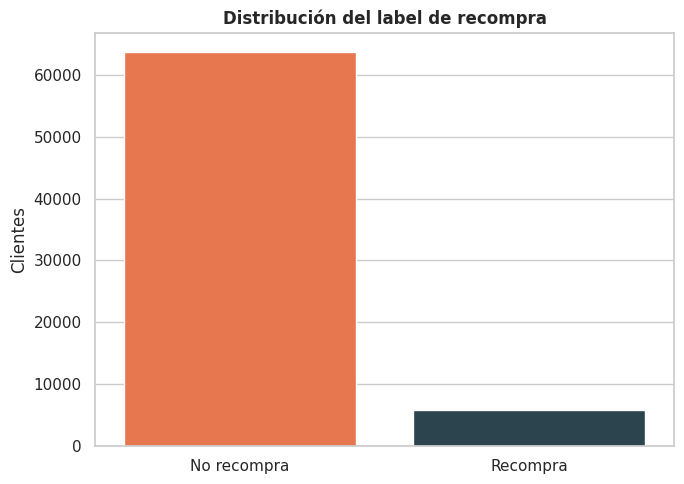

Baseline de la clase mayoritaria: 91.71%
Validación del label aprobada: existen clientes con recompra y sin recompra.


In [ ]:
label_column = "label_repeat_purchase_90d"

label_summary = (
    feature_df[label_column]
    .value_counts()
    .sort_index()
    .rename_axis(label_column)
    .reset_index(name="customers")
)
label_summary["share"] = label_summary["customers"] / label_summary["customers"].sum()
label_summary["outcome"] = label_summary[label_column].map({0: "No recompra", 1: "Recompra"})

display(label_summary.style.format({"customers": "{:,.0f}", "share": "{:.2%}"}))

plt.figure(figsize=(7, 5))
sns.barplot(data=label_summary, x="outcome", y="customers", hue="outcome", palette=COLORS[:2], legend=False)
plt.title("Distribución del label de recompra")
plt.xlabel("")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

majority_baseline = label_summary["share"].max()
print(f"Baseline de la clase mayoritaria: {majority_baseline:.2%}")

observed_labels = set(feature_df[label_column].dropna().astype(int).unique())

if observed_labels != {0, 1}:
    raise ValueError(
        f"El label debe contener las clases 0 y 1. Clases encontradas: {sorted(observed_labels)}"
    )

print("Validación del label aprobada: existen clientes con recompra y sin recompra.")

Después de definir la recompra a 90 días como label, validamos su distribución. De los 69,548 clientes elegibles, 5,786 recompraron y 63,762 no lo hicieron. Esto representa una tasa de recompra de 8.32% y evidencia un desbalance de clases que deberá considerarse en la evaluación de los modelos posteriores.

## 10. Análisis univariado de las features

Se revisan tendencia central, dispersión, percentiles, asimetría y valores extremos. `log1p` se utiliza únicamente para visualizar variables con cola derecha.

In [ ]:
numeric_features = [
    "first_order_items",
    "first_order_lines",
    "first_order_value",
    "pre_purchase_events",
    "pre_purchase_sessions",
    "pre_purchase_active_days",
    "home_events",
    "department_events",
    "product_events",
    "cart_events",
    "distinct_pages",
    "seconds_from_first_event_to_order",
    "age",
    "days_from_signup_to_first_order"
]

numeric_summary = feature_df[numeric_features].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T
numeric_summary["missing"] = feature_df[numeric_features].isna().sum()
numeric_summary["skewness"] = feature_df[numeric_features].skew(numeric_only=True)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing,skewness
first_order_items,"69,393.00",1.45,0.80,1.00,1.00,1.00,2.00,3.00,3.00,4.00,4.00,0,1.88
first_order_lines,"69,393.00",1.45,0.80,1.00,1.00,1.00,2.00,3.00,3.00,4.00,4.00,0,1.88
first_order_value,"69,393.00",86.24,93.64,0.02,29.50,55.00,109.91,191.54,256.98,424.50,"1,660.99",0,3.55
pre_purchase_events,"69,393.00",8.78,10.23,1.00,4.00,4.00,12.00,16.00,27.00,48.00,48.00,0,2.72
pre_purchase_sessions,"69,393.00",1.45,0.80,1.00,1.00,1.00,2.00,3.00,3.00,4.00,4.00,0,1.88
pre_purchase_active_days,"69,393.00",1.02,0.15,1.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,0,6.17
home_events,"69,393.00",0.70,0.46,0.00,0.00,1.00,1.00,1.00,1.00,1.00,2.00,0,-0.86
department_events,"69,393.00",2.71,3.54,0.00,1.00,1.00,4.00,6.00,9.00,16.00,16.00,0,2.61
product_events,"69,393.00",2.69,3.52,0.00,1.00,1.00,4.00,5.80,9.00,16.00,16.00,0,2.61
cart_events,"69,393.00",2.68,3.51,0.00,1.00,1.00,4.00,5.00,9.00,16.00,16.00,0,2.62


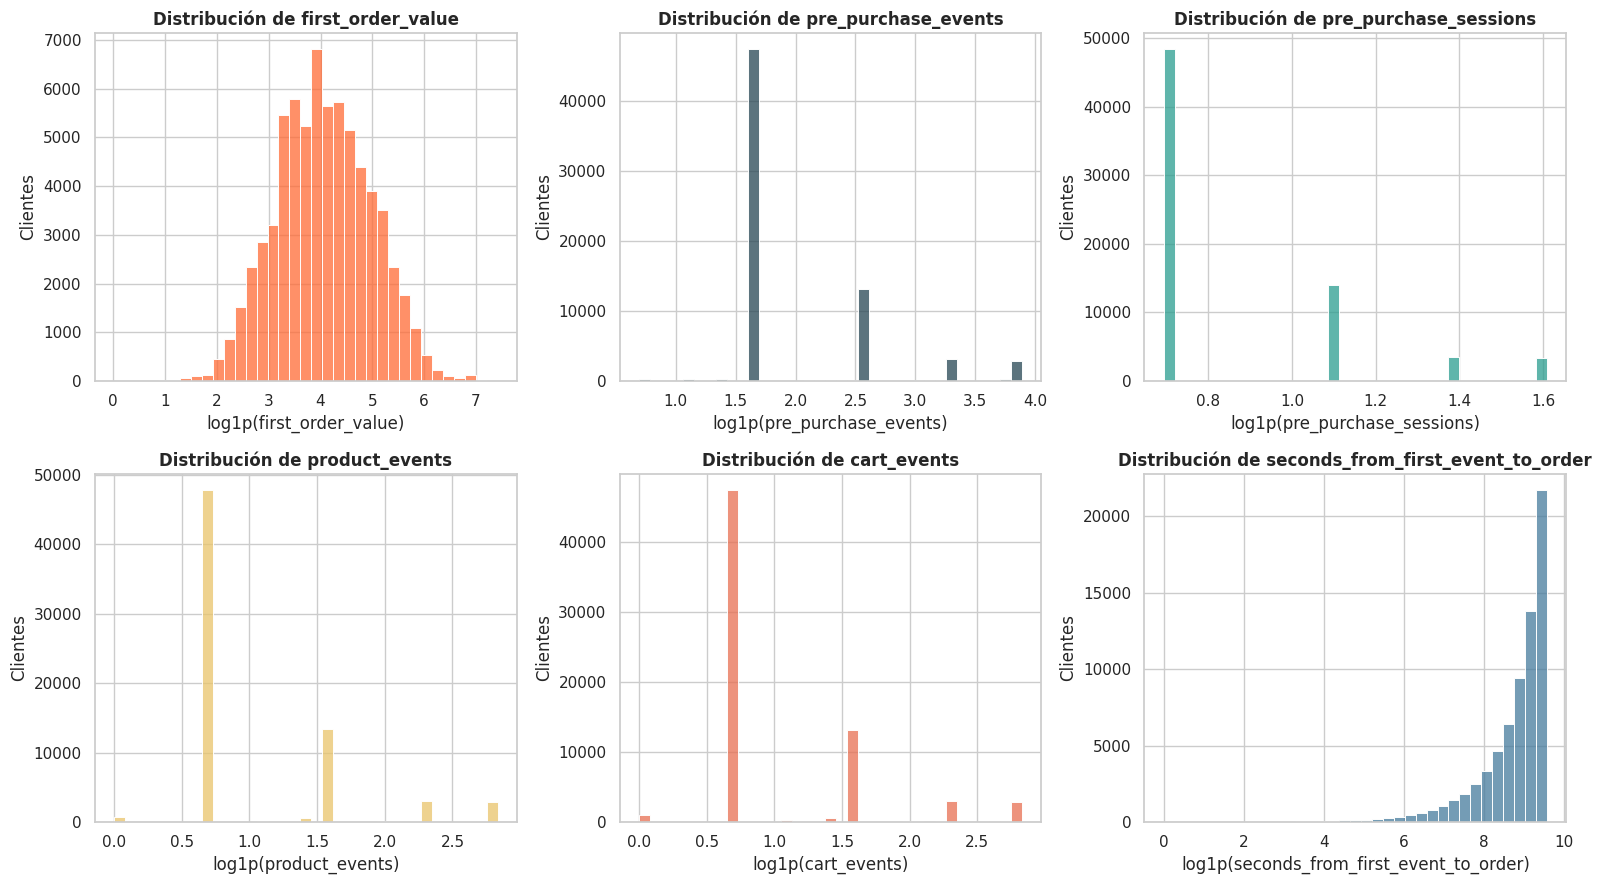

In [ ]:
plot_features = [
    "first_order_value",
    "pre_purchase_events",
    "pre_purchase_sessions",
    "product_events",
    "cart_events",
    "seconds_from_first_event_to_order"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for column, ax, color in zip(plot_features, axes.flat, COLORS):
    sns.histplot(np.log1p(feature_df[column].clip(lower=0)), bins=35, color=color, ax=ax)
    ax.set_title(f"Distribución de {column}")
    ax.set_xlabel(f"log1p({column})")
    ax.set_ylabel("Clientes")

plt.tight_layout()
plt.show()

- La primera compra contiene en promedio 1.45 artículos; la mediana es 1 y el máximo es 4. Esto indica que la mayoría comienza con una compra pequeña.
- El valor promedio de la primera orden es 86.23, mientras que la mediana es 55.38. La diferencia se debe a una minoría de compras de valor muy alto.
- El 75% de las primeras órdenes no supera 109.99, el 90% no supera 190 y el máximo alcanza 1,296.49.
- Antes de comprar, cada cliente genera en promedio 8.79 eventos, pero la mediana es solamente 4. Esto indica que la mayoría realiza pocas acciones, mientras un grupo menor presenta recorridos mucho más largos.
- El 75% de los clientes genera hasta 12 eventos antes de comprar, mientras que los clientes con mayor actividad alcanzan hasta 48.
- La mayoría realiza su primera compra dentro de una sola sesión. La mediana de pre_purchase_sessions es 1 y el 75% necesita como máximo 2 sesiones.
- Antes de la primera orden, los clientes registran en promedio aproximadamente 2.7 visitas a departamentos, 2.7 vistas de producto y 2.7 acciones de carrito.
- El cliente visita una mediana de 4 páginas distintas antes de comprar; el 90% visita como máximo 6 y el máximo observado es 10.
- El tiempo promedio desde el primer evento hasta la orden es de 8,093 segundos, aproximadamente 2 horas y 15 minutos. La mediana es de aproximadamente 2 horas y 22 minutos.
- El 75% completa su primera compra en menos de 3 horas y 16 minutos, y prácticamente todos lo hacen dentro de las primeras 4 horas.
- La edad promedio y mediana es de 41 años, con un rango de 12 a 70 años. Su asimetría es 0, por lo que presenta una distribución equilibrada.
- Entre el registro y la primera orden transcurren en promedio 603 días, pero la mediana es 427 días, aproximadamente 14 meses. La distribución está sesgada hacia clientes que tardaron mucho más en realizar su primera compra.

Nota: consideramos que para preparar el clustering, conviene aplicar log1p a las variables con fuerte asimetría y posteriormente estandarizarlas. También deben retirarse variables redundantes como first_order_lines o first_order_items.

## 11. Features y recompra

Las medias y medianas por clase permiten identificar diferencias iniciales. Son asociaciones exploratorias y no prueban causalidad ni desempeño predictivo.

In [ ]:
summary_by_label = (
    feature_df.groupby(label_column)[numeric_features]
    .agg(["mean", "median"])
    .T
)
summary_by_label.columns = ["no_repeat_purchase", "repeat_purchase"]
summary_by_label["difference"] = (
    summary_by_label["repeat_purchase"] - summary_by_label["no_repeat_purchase"]
)

display(summary_by_label.sort_values("difference", ascending=False))

,,no_repeat_purchase,repeat_purchase,difference
seconds_from_first_event_to_order,median,"8,489.00","8,579.50",90.50
home_events,mean,0.70,0.70,0.00
pre_purchase_active_days,mean,1.02,1.03,0.00
product_events,median,1.00,1.00,0.00
cart_events,median,1.00,1.00,0.00
first_order_lines,median,1.00,1.00,0.00
age,median,41.00,41.00,0.00
first_order_value,median,55.00,55.00,0.00
pre_purchase_events,median,4.00,4.00,0.00
pre_purchase_sessions,median,1.00,1.00,0.00


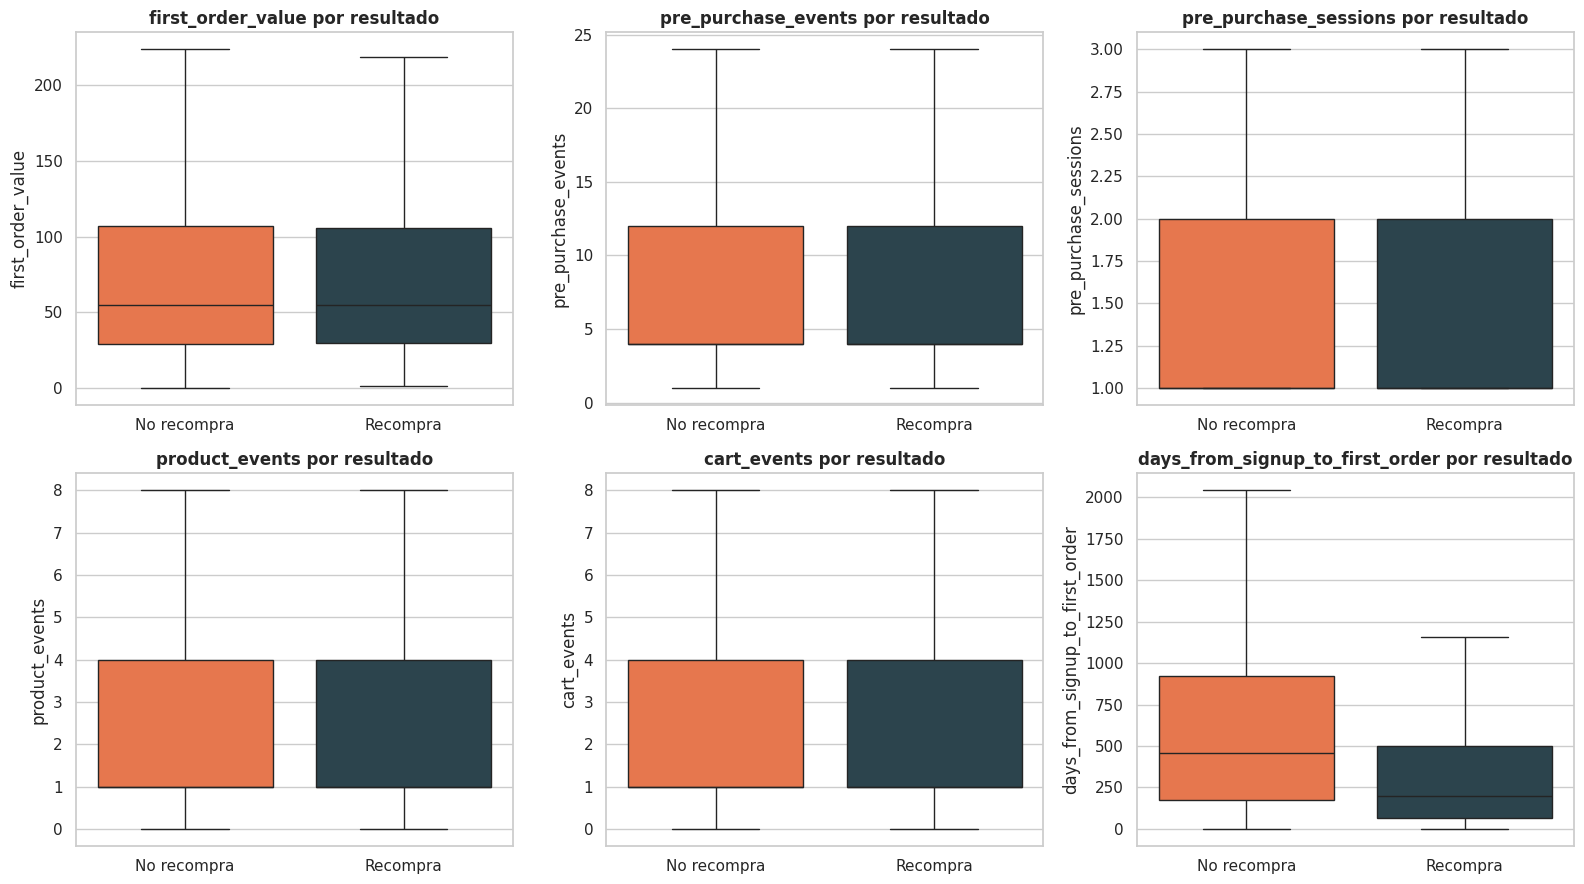

In [ ]:
comparison_features = [
    "first_order_value",
    "pre_purchase_events",
    "pre_purchase_sessions",
    "product_events",
    "cart_events",
    "days_from_signup_to_first_order"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for column, ax in zip(comparison_features, axes.flat):
    cap = feature_df[column].quantile(0.99)
    plot_data = feature_df.loc[feature_df[column].le(cap), [label_column, column]].copy()
    plot_data["outcome"] = plot_data[label_column].map({0: "No recompra", 1: "Recompra"})
    sns.boxplot(
        data=plot_data,
        x="outcome",
        y=column,
        hue="outcome",
        palette=COLORS[:2],
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f"{column} por resultado")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

Las variables relacionadas con el valor y la navegación inicial muestran distribuciones muy similares entre ambos resultados. La diferencia más evidente aparece en el tiempo desde el registro hasta la primera compra: los clientes que compran más pronto después de registrarse presentan una mayor tendencia a recomprar dentro de 90 días.

## 12. Recompra por categorías de negocio

Se reportan volumen y tasa de recompra. Los filtros mínimos evitan interpretar categorías con muy pocos clientes.

In [ ]:
def categorical_repeat_rate(frame, column, minimum_customers=100):
    return (
        frame.groupby(column, dropna=False)
        .agg(
            customers=("user_id", "nunique"),
            repeat_rate=(label_column, "mean")
        )
        .query("customers >= @minimum_customers")
        .sort_values("customers", ascending=False)
        .reset_index()
    )

traffic_summary = categorical_repeat_rate(feature_df, "traffic_source")
country_summary = categorical_repeat_rate(feature_df, "country", minimum_customers=250)

display(traffic_summary.style.format({"customers": "{:,.0f}", "repeat_rate": "{:.2%}"}))
display(country_summary.head(15).style.format({"customers": "{:,.0f}", "repeat_rate": "{:.2%}"}))

,traffic_source,customers,repeat_rate
0,Search,"48,494",8.32%
1,Organic,"10,335",8.35%
2,Facebook,"4,261",7.93%
3,Email,"3,509",8.44%
4,Display,"2,794",7.84%


,country,customers,repeat_rate
0,China,"23,815",8.19%
1,United States,"15,315",8.50%
2,Brasil,"10,055",8.33%
3,South Korea,"3,683",7.79%
4,United Kingdom,"3,245",8.81%
5,France,"3,235",8.32%
6,Germany,"2,935",7.56%
7,Spain,"2,845",8.05%
8,Japan,"1,740",8.22%
9,Australia,"1,506",8.63%


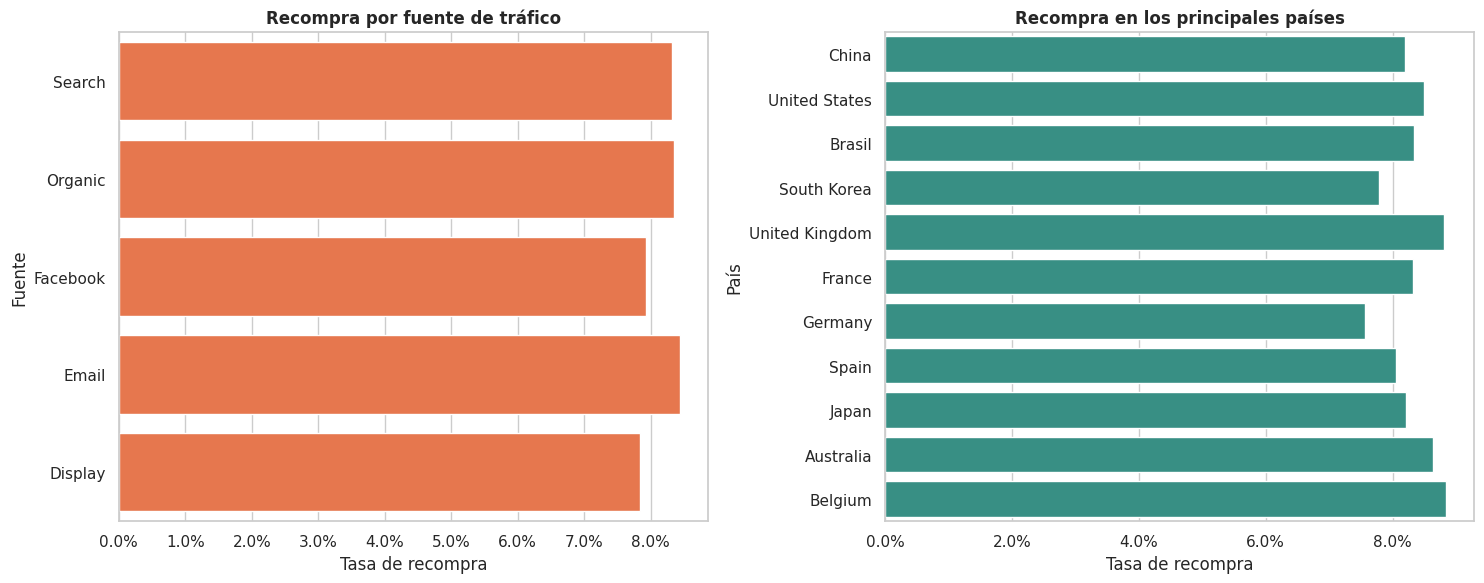

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=traffic_summary, y="traffic_source", x="repeat_rate", color=COLORS[0], ax=axes[0])
axes[0].set_title("Recompra por fuente de tráfico")
axes[0].set_xlabel("Tasa de recompra")
axes[0].set_ylabel("Fuente")
axes[0].xaxis.set_major_formatter(lambda value, _: f"{value:.1%}")

country_view = country_summary.sort_values("customers", ascending=False).head(15)
sns.barplot(data=country_view, y="country", x="repeat_rate", color=COLORS[2], ax=axes[1])
axes[1].set_title("Recompra en los principales países")
axes[1].set_xlabel("Tasa de recompra")
axes[1].set_ylabel("País")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.1%}")

plt.tight_layout()
plt.show()

## 13. Correlaciones numéricas

Se utiliza Spearman porque varias variables son discretas o asimétricas. La correlación indica asociación monotónica, no causalidad.

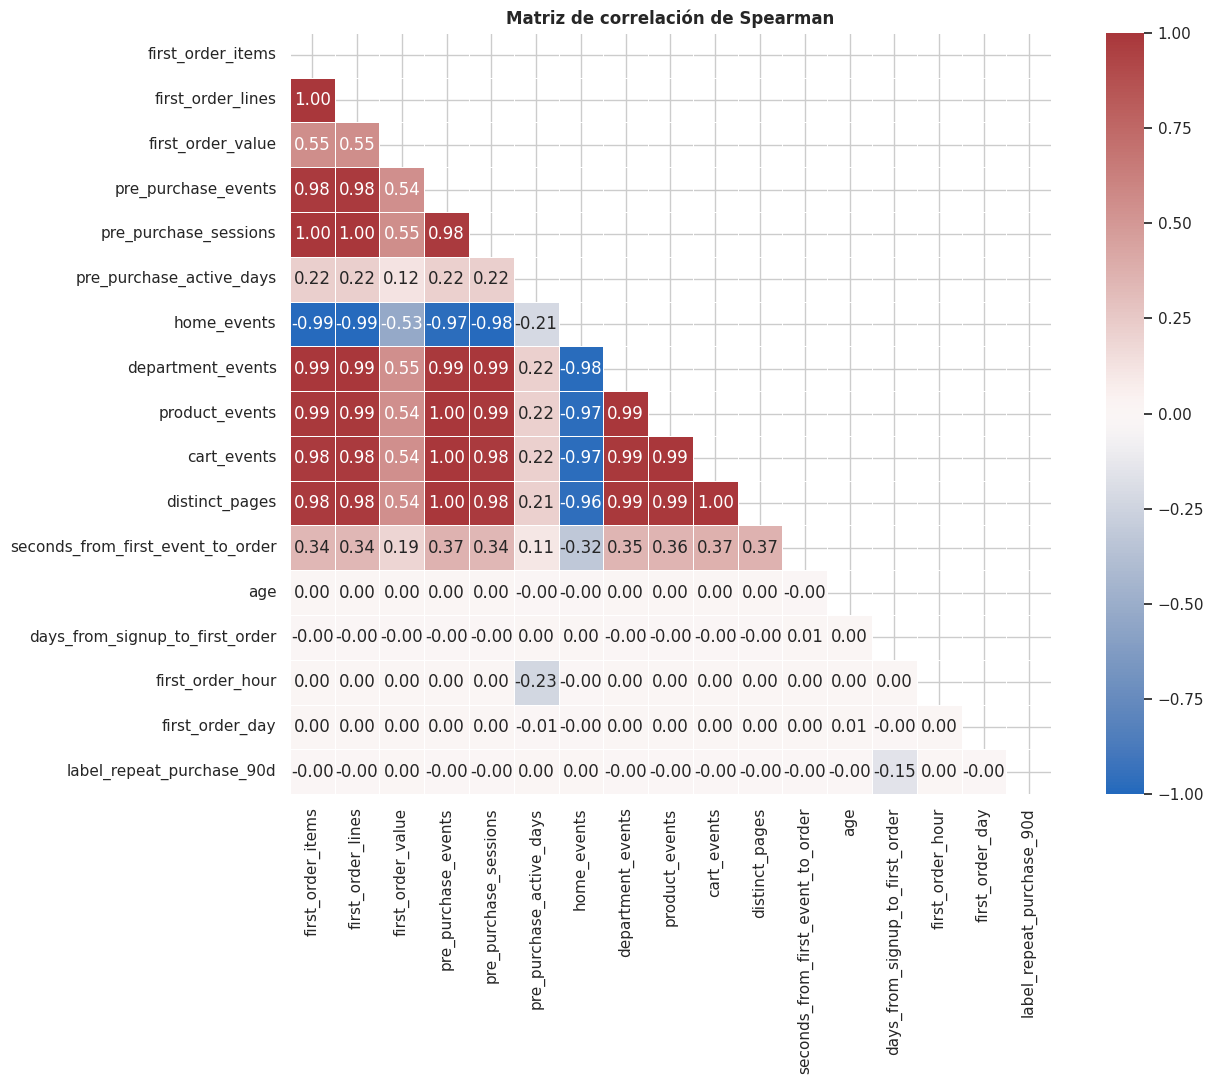

,spearman_with_label
days_from_signup_to_first_order,-0.15
pre_purchase_active_days,0.00
age,-0.00
first_order_day,-0.00
home_events,0.00
product_events,-0.00
first_order_items,-0.00
first_order_lines,-0.00
department_events,-0.00
pre_purchase_events,-0.00


In [ ]:
correlation_features = numeric_features + [
    "first_order_hour",
    "first_order_day",
    label_column
]

spearman_corr = feature_df[correlation_features].corr(method="spearman")
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

target_correlations = (
    spearman_corr[label_column]
    .drop(label_column)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("spearman_with_label")
)
display(target_correlations.to_frame())

El análisis no encontró correlaciones fuertes entre las características iniciales y la recompra a 90 días. La asociación más visible fue days_from_signup_to_first_order, con una correlación débil de −0.15. En cambio, sí se detectó alta redundancia entre las variables de navegación

## 14. Diagnóstico de valores extremos


In [ ]:
outlier_rows = []

for column in numeric_features:
    series = feature_df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    outlier_rows.append({
        "feature": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": outliers,
        "outlier_pct": outliers / len(series) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_summary.style.format({"outliers": "{:,.0f}", "outlier_pct": "{:.2f}%"}))

,feature,lower_bound,upper_bound,outliers,outlier_pct
10,distinct_pages,2.500000,6.500000,"7,510",10.82%
3,pre_purchase_events,-8.000000,24.000000,"6,560",9.45%
7,department_events,-3.500000,8.500000,"6,560",9.45%
8,product_events,-3.500000,8.500000,"6,504",9.37%
9,cart_events,-3.500000,8.500000,"6,438",9.28%
2,first_order_value,-91.115005,230.525009,"4,536",6.54%
0,first_order_items,-0.500000,3.500000,"3,420",4.93%
4,pre_purchase_sessions,-0.500000,3.500000,"3,420",4.93%
1,first_order_lines,-0.500000,3.500000,"3,420",4.93%
13,days_from_signup_to_first_order,-962.000000,2038.000000,"1,704",2.46%


El diagnóstico detectó una mayor concentración de valores atípicos en las variables de navegación. Sin embargo, estos casos representan clientes con mayor actividad y no necesariamente errores. Por ello no se eliminaron automáticamente; se conservaron y se aplicó una transformación logarítmica para reducir su influencia en futuros modelos o procesos de clustering.

## 15. Preprocesamiento inicial para clasificación

Los identificadores y timestamps se excluyen. Las variables numéricas se imputan con mediana y estandarizan; las categóricas se completan con la moda y se codifican con one-hot. La división es temporal para evaluar clientes futuros.

In [ ]:
classification_numeric = [
    "first_order_hour",
    "first_order_day",
    "first_order_items",
    "first_order_lines",
    "first_order_value",
    "pre_purchase_events",
    "pre_purchase_sessions",
    "pre_purchase_active_days",
    "home_events",
    "department_events",
    "product_events",
    "cart_events",
    "distinct_pages",
    "seconds_from_first_event_to_order",
    "pre_purchase_history_missing",
    "age",
    "age_was_missing",
    "days_from_signup_to_first_order"
]

classification_categorical = ["gender", "country", "traffic_source"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, classification_numeric),
    ("categorical", categorical_pipeline, classification_categorical)
])

X = feature_df[classification_numeric + classification_categorical].copy()
y = feature_df[label_column].astype(int)

ordered_index = feature_df.sort_values("first_order_at").index
cutoff_position = int(len(ordered_index) * 0.80)
train_index = ordered_index[:cutoff_position]
test_index = ordered_index[cutoff_position:]

X_train = X.loc[train_index]
X_test = X.loc[test_index]
y_train = y.loc[train_index]
y_test = y.loc[test_index]

X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print(f"Train: {len(X_train):,} clientes")
print(f"Test: {len(X_test):,} clientes")
print(f"Recompra train: {y_train.mean():.2%}")
print(f"Recompra test: {y_test.mean():.2%}")
print(f"Columnas transformadas: {X_train_ready.shape[1]:,}")
print(f"Inicio de test: {feature_df.loc[test_index, 'first_order_at'].min()}")

Train: 55,514 clientes
Test: 13,879 clientes
Recompra train: 6.31%
Recompra test: 16.20%
Columnas transformadas: 39
Inicio de test: 2025-10-30 08:59:47+00:00


Los clientes fueron separados temporalmente: el 80% más antiguo se destinó a entrenamiento y el 20% más reciente a prueba. Las variables categóricas se transformaron mediante one-hot encoding para representarlas como columnas binarias sin crear órdenes artificiales. Después del procesamiento quedaron 40 columnas. También se detectó un cambio temporal importante: la recompra aumentó de 6.39% en train a 16.02% en test, lo que deberá considerarse en la evaluación de un modelo futuro.

## 16. Definición del clustering

**Pregunta:** ¿Existen arquetipos de clientes según su comportamiento hasta la primera compra y presentan diferentes tasas de recompra durante los 90 días posteriores?

Cada fila representa un cliente elegible identificado mediante `user_id`.

Variables utilizadas para calcular similitud:

- `first_order_value`: valor de la primera orden.
- `pre_purchase_events`: actividad antes de comprar.
- `seconds_from_first_event_to_order`: rapidez de decisión.
- `days_from_signup_to_first_order`: tiempo entre registro y primera compra.

Las variables redundantes se excluyen para no representar varias veces el mismo comportamiento.

`gender`, `country` y `traffic_source` no se incluyen en la distancia. Se utilizan después para describir los arquetipos. En un modelo supervisado futuro se transformarán mediante one-hot encoding.

El label no se utiliza para crear los clusters. Solamente se usa después para comparar la tasa de recompra de cada arquetipo.

## 17. Acondicionamiento de variables para K-Means

El clustering exploratorio se realiza con los 69,548 clientes elegibles porque el objetivo es descubrir los arquetipos presentes en toda la población analizada.

Las variables `first_order_value`, `pre_purchase_events` y `days_from_signup_to_first_order` presentan asimetría positiva, por lo que se transforman mediante `log1p`. Esta transformación reduce la influencia de valores elevados sin eliminar clientes.

`seconds_from_first_event_to_order` se conserva sin transformación logarítmica porque no presentó una asimetría positiva fuerte.

Posteriormente, todas las variables se estandarizan para que dólares, eventos, segundos y días sean comparables y ninguna variable domine la distancia únicamente por su escala.

Los valores faltantes se imputan con la mediana del conjunto completo. Este uso es válido para el análisis exploratorio de clustering porque no se está evaluando todavía el desempeño sobre clientes futuros.

`log1p` reduce la influencia de valores elevados sin eliminar clientes. La estandarización permite comparar dólares, eventos, segundos y días dentro de una misma distancia.

In [ ]:
cluster_features = [
    "first_order_value",
    "pre_purchase_events",
    "seconds_from_first_event_to_order",
    "days_from_signup_to_first_order"
]

cluster_log_features = [
    "first_order_value",
    "pre_purchase_events",
    "days_from_signup_to_first_order"
]

cluster_input = (
    feature_df[cluster_features]
    .astype(float)
    .copy()
)

cluster_medians = cluster_input.median()

cluster_input = cluster_input.fillna(
    cluster_medians
)

cluster_transformed = cluster_input.copy()

for column in cluster_log_features:
    cluster_transformed[column] = np.log1p(
        cluster_transformed[column].clip(lower=0)
    )

cluster_means = cluster_transformed.mean()

cluster_stds = (
    cluster_transformed
    .std(ddof=0)
    .replace(0, 1)
)

cluster_scaled = (
    cluster_transformed - cluster_means
) / cluster_stds

X_cluster = cluster_scaled.to_numpy()

print(f"Clientes utilizados: {X_cluster.shape[0]:,}")
print(f"Variables utilizadas: {X_cluster.shape[1]}")

display(cluster_scaled.describe().T)

Clientes utilizados: 69,393
Variables utilizadas: 4


,count,mean,std,min,25%,50%,75%,max
first_order_value,"69,393.00",-0.00,1.00,-4.43,-0.70,-0.03,0.72,3.69
pre_purchase_events,"69,393.00",0.00,1.00,-1.96,-0.57,-0.57,0.87,2.88
seconds_from_first_event_to_order,"69,393.00",0.00,1.00,-1.95,-0.83,0.10,0.88,1.53
days_from_signup_to_first_order,"69,393.00",-0.00,1.00,-4.36,-0.54,0.20,0.75,1.56


## 18. Implementación manual de K-Means

El algoritmo inicializa centroides, calcula distancias, asigna cada cliente al centroide más cercano, recalcula los centroides y repite el proceso hasta alcanzar convergencia.

In [ ]:
def normalize_rows(matrix):
    norms = np.linalg.norm(
        matrix,
        axis=1,
        keepdims=True
    )

    return matrix / np.where(
        norms == 0,
        1,
        norms
    )


def distance_matrix(matrix, centroids, metric):
    if metric == "euclidean":
        differences = (
            matrix[:, None, :]
            - centroids[None, :, :]
        )

        return np.sqrt(
            np.square(differences).sum(axis=2)
        )

    if metric == "cosine":
        normalized_matrix = normalize_rows(matrix)
        normalized_centroids = normalize_rows(centroids)

        return (
            1
            - normalized_matrix
            @ normalized_centroids.T
        )

    raise ValueError(
        "La métrica debe ser euclidean o cosine"
    )


def kmeans_once_manual(
    matrix,
    k,
    metric="euclidean",
    max_iter=100,
    tol=1e-4,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    if metric == "cosine":
        work_matrix = normalize_rows(matrix)
    else:
        work_matrix = matrix.copy()

    initial_positions = rng.choice(
        len(work_matrix),
        size=k,
        replace=False
    )

    centroids = work_matrix[
        initial_positions
    ].copy()

    previous_labels = None

    for iteration in range(1, max_iter + 1):
        distances = distance_matrix(
            work_matrix,
            centroids,
            metric
        )

        labels = distances.argmin(axis=1)
        new_centroids = np.empty_like(centroids)

        for cluster in range(k):
            members = work_matrix[
                labels == cluster
            ]

            if len(members) == 0:
                position = rng.integers(
                    len(work_matrix)
                )

                new_centroids[cluster] = (
                    work_matrix[position]
                )
            else:
                new_centroids[cluster] = (
                    members.mean(axis=0)
                )

        if metric == "cosine":
            new_centroids = normalize_rows(
                new_centroids
            )

        movement = np.linalg.norm(
            new_centroids - centroids
        )

        same_labels = (
            previous_labels is not None
            and np.array_equal(
                labels,
                previous_labels
            )
        )

        centroids = new_centroids

        if same_labels or movement < tol:
            break

        previous_labels = labels.copy()

    final_distances = distance_matrix(
        work_matrix,
        centroids,
        metric
    )

    labels = final_distances.argmin(axis=1)

    minimum_distances = final_distances[
        np.arange(len(work_matrix)),
        labels
    ]

    if metric == "euclidean":
        objective = np.square(
            minimum_distances
        ).sum()
    else:
        objective = minimum_distances.sum()

    return {
        "labels": labels,
        "centroids": centroids,
        "objective": objective,
        "iterations": iteration
    }


def kmeans_manual(
    matrix,
    k,
    metric="euclidean",
    n_init=5,
    max_iter=100,
    tol=1e-4,
    random_state=42
):
    best_result = None

    for start in range(n_init):
        result = kmeans_once_manual(
            matrix=matrix,
            k=k,
            metric=metric,
            max_iter=max_iter,
            tol=tol,
            random_state=random_state + start
        )

        if (
            best_result is None
            or result["objective"]
            < best_result["objective"]
        ):
            best_result = result

    return best_result

## 19. Selección de K

Se prueban valores de K entre 2 y 7. La selección considera el método del codo, Silhouette Score y la interpretación de los arquetipos.

In [ ]:
from sklearn.metrics import silhouette_score

cluster_results = []
cluster_runs = {}

for metric in ["euclidean", "cosine"]:
    for k in range(2, 8):
        result = kmeans_manual(
            matrix=X_cluster,
            k=k,
            metric=metric,
            n_init=5,
            max_iter=100,
            random_state=42
        )

        silhouette = silhouette_score(
            X_cluster,
            result["labels"],
            metric=metric,
            sample_size=min(
                10000,
                len(X_cluster)
            ),
            random_state=42
        )

        cluster_runs[(metric, k)] = result

        cluster_results.append({
            "metric": metric,
            "k": k,
            "objective": result["objective"],
            "silhouette": silhouette,
            "iterations": result["iterations"]
        })

cluster_evaluation = pd.DataFrame(
    cluster_results
)

display(
    cluster_evaluation.sort_values(
        ["metric", "k"]
    )
)

,metric,k,objective,silhouette,iterations
6,cosine,2,"31,410.19",0.43,26
7,cosine,3,"21,721.69",0.46,24
8,cosine,4,"16,769.24",0.48,45
9,cosine,5,"14,209.71",0.47,47
10,cosine,6,"12,485.93",0.46,52
11,cosine,7,"11,177.18",0.45,61
0,euclidean,2,"193,096.92",0.31,22
1,euclidean,3,"155,593.05",0.26,34
2,euclidean,4,"127,413.17",0.27,29
3,euclidean,5,"112,810.57",0.26,49


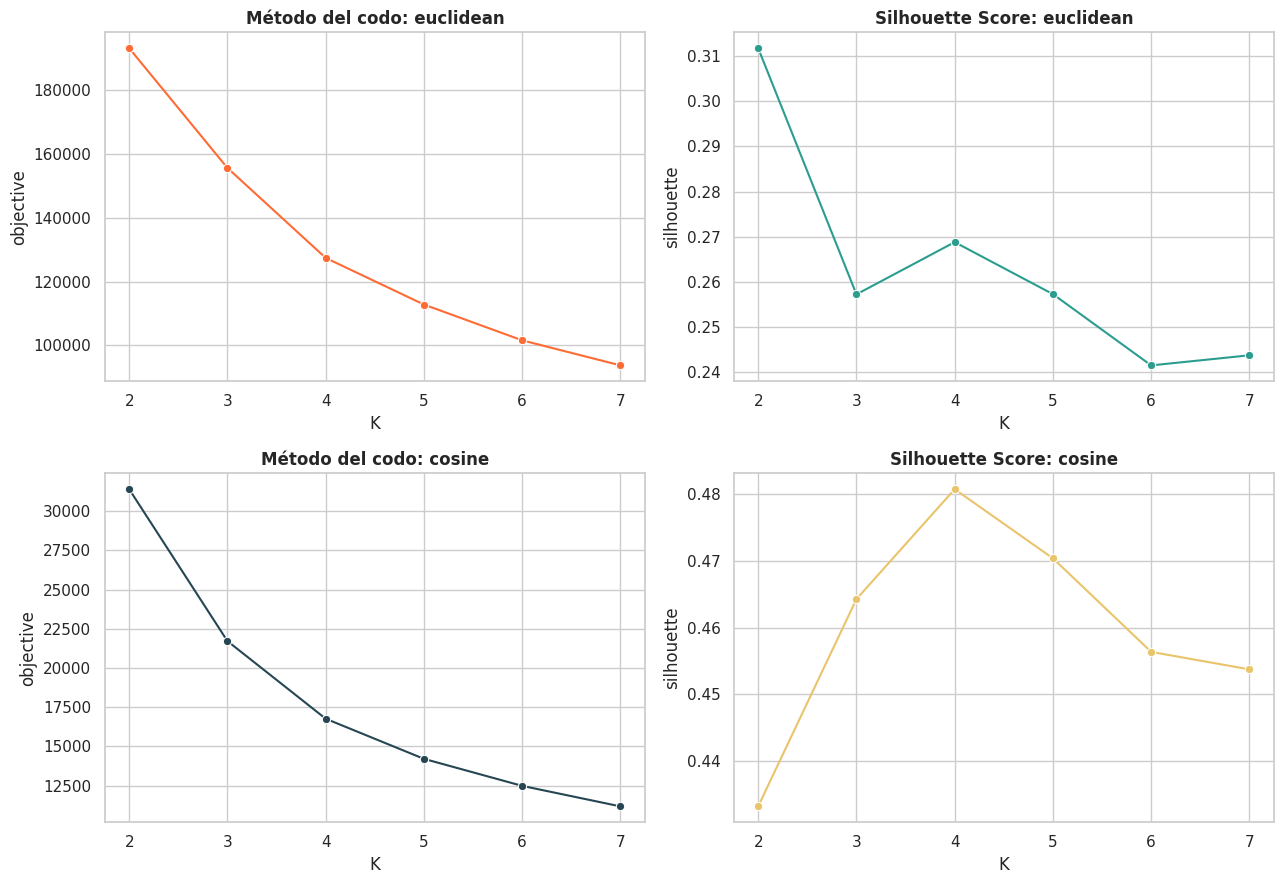

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)

for row, metric in enumerate(
    ["euclidean", "cosine"]
):
    metric_results = cluster_evaluation.query(
        "metric == @metric"
    )

    sns.lineplot(
        data=metric_results,
        x="k",
        y="objective",
        marker="o",
        color=COLORS[row],
        ax=axes[row, 0]
    )

    sns.lineplot(
        data=metric_results,
        x="k",
        y="silhouette",
        marker="o",
        color=COLORS[row + 2],
        ax=axes[row, 1]
    )

    axes[row, 0].set_title(
        f"Método del codo: {metric}"
    )

    axes[row, 1].set_title(
        f"Silhouette Score: {metric}"
    )

    axes[row, 0].set_xlabel("K")
    axes[row, 1].set_xlabel("K")

plt.tight_layout()
plt.show()

In [ ]:
# Juntar ambas graficas para el metodo del codo seno y coseno


In [ ]:
silhouette_by_k = (
    cluster_evaluation
    .groupby("k", as_index=False)
    .agg(
        average_silhouette=(
            "silhouette",
            "mean"
        )
    )
    .sort_values(
        "average_silhouette",
        ascending=False
    )
)

display(silhouette_by_k)

suggested_k = int(
    silhouette_by_k.iloc[0]["k"]
)

print(
    f"Se seleccionó K sugerido: {suggested_k} para representar un equilibrio entre la reducción de la función objetivo, el Silhouette Score y la interpretación de los grupos."
)

,k,average_silhouette
2,4,0.37
0,2,0.37
3,5,0.36
1,3,0.36
4,6,0.35
5,7,0.35


Se seleccionó K sugerido: 4 para representar un equilibrio entre la reducción de la función objetivo, el Silhouette Score y la interpretación de los grupos.


## 20. Euclidiana contra Coseno

Euclidiana agrupa clientes con magnitudes cercanas. Coseno agrupa clientes con patrones relativos similares, aunque sus magnitudes sean diferentes.

Se utiliza el mismo K para comparar únicamente el efecto de la medida de similitud.

In [ ]:
selected_k = suggested_k

euclidean_result = cluster_runs[
    ("euclidean", selected_k)
]

cosine_result = cluster_runs[
    ("cosine", selected_k)
]

feature_df["cluster_euclidean"] = (
    euclidean_result["labels"]
)

feature_df["cluster_cosine"] = (
    cosine_result["labels"]
)

print(f"K seleccionado: {selected_k}")
print(
    f"Iteraciones Euclidiana: "
    f"{euclidean_result['iterations']}"
)
print(
    f"Iteraciones Coseno: "
    f"{cosine_result['iterations']}"
)

K seleccionado: 4
Iteraciones Euclidiana: 29
Iteraciones Coseno: 45


In [ ]:
from sklearn.metrics import adjusted_rand_score

comparison_ari = adjusted_rand_score(
    feature_df["cluster_euclidean"],
    feature_df["cluster_cosine"]
)

comparison_table = pd.crosstab(
    feature_df["cluster_euclidean"],
    feature_df["cluster_cosine"],
    normalize="index"
)

print(
    f"Adjusted Rand Index: {comparison_ari:.3f}"
)

display(
    comparison_table.style.format(
        "{:.1%}"
    )
)

Adjusted Rand Index: 0.778


cluster_cosine,0,1,2,3
cluster_euclidean,,,,
0,4.4%,7.5%,80.3%,7.8%
1,91.6%,5.0%,0.0%,3.4%
2,0.0%,96.2%,0.0%,3.8%
3,0.0%,0.0%,0.0%,100.0%


El Adjusted Rand Index mide la semejanza entre las asignaciones. Un valor cercano a 1 indica resultados similares; un valor cercano a 0 indica que la medida de similitud cambió considerablemente los grupos.

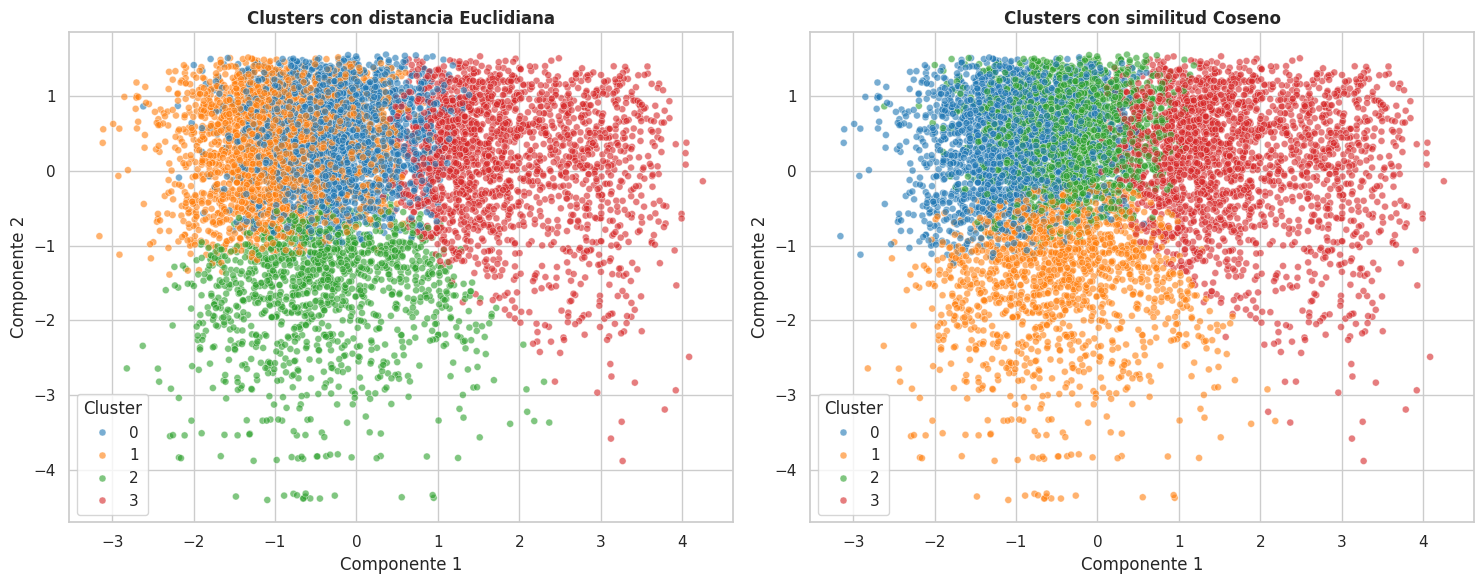

Varianza explicada: 68.66%


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

pca_coordinates = pca.fit_transform(
    X_cluster
)

rng = np.random.default_rng(42)

sample_positions = rng.choice(
    len(pca_coordinates),
    size=min(8000, len(pca_coordinates)),
    replace=False
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.scatterplot(
    x=pca_coordinates[sample_positions, 0],
    y=pca_coordinates[sample_positions, 1],
    hue=feature_df["cluster_euclidean"]
        .to_numpy()[sample_positions],
    palette="tab10",
    s=25,
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title(
    "Clusters con distancia Euclidiana"
)
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[0].legend(title="Cluster")

sns.scatterplot(
    x=pca_coordinates[sample_positions, 0],
    y=pca_coordinates[sample_positions, 1],
    hue=feature_df["cluster_cosine"]
        .to_numpy()[sample_positions],
    palette="tab10",
    s=25,
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title(
    "Clusters con similitud Coseno"
)
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

print(
    "Varianza explicada:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

PCA se utiliza únicamente para visualizar los clusters en dos dimensiones. K-Means se ejecutó con las cuatro variables seleccionadas.

In [ ]:
def dominant_category(values):
    modes = values.mode()

    if len(modes) == 0:
        return "Unknown"

    return modes.iloc[0]


def create_cluster_profile(
    frame,
    cluster_column
):
    profile = (
        frame
        .groupby(cluster_column)
        .agg(
            customers=("user_id", "nunique"),
            first_order_value=(
                "first_order_value",
                "median"
            ),
            first_order_items=(
                "first_order_items",
                "median"
            ),
            pre_purchase_events=(
                "pre_purchase_events",
                "median"
            ),
            seconds_to_order=(
                "seconds_from_first_event_to_order",
                "median"
            ),
            signup_to_order_days=(
                "days_from_signup_to_first_order",
                "median"
            ),
            age=("age", "median"),
            dominant_gender=(
                "gender",
                dominant_category
            ),
            dominant_country=(
                "country",
                dominant_category
            ),
            dominant_traffic_source=(
                "traffic_source",
                dominant_category
            ),
            repeat_rate=(
                "label_repeat_purchase_90d",
                "mean"
            )
        )
        .reset_index()
    )

    profile["customer_share"] = (
        profile["customers"]
        / profile["customers"].sum()
    )

    return profile


euclidean_profile = create_cluster_profile(
    feature_df,
    "cluster_euclidean"
)

cosine_profile = create_cluster_profile(
    feature_df,
    "cluster_cosine"
)

print("Perfil Euclidiana")

display(
    euclidean_profile.style.format({
        "customers": "{:,.0f}",
        "customer_share": "{:.2%}",
        "first_order_value": "${:,.2f}",
        "repeat_rate": "{:.2%}"
    })
)

print("Perfil Coseno")

display(
    cosine_profile.style.format({
        "customers": "{:,.0f}",
        "customer_share": "{:.2%}",
        "first_order_value": "${:,.2f}",
        "repeat_rate": "{:.2%}"
    })
)

Perfil Euclidiana


,cluster_euclidean,customers,first_order_value,first_order_items,pre_purchase_events,seconds_to_order,signup_to_order_days,age,dominant_gender,dominant_country,dominant_traffic_source,repeat_rate,customer_share
0,0,"20,517",$37.82,1.000000,4.000000,10957.000000,617.000000,41.000000,F,China,Search,6.51%,29.57%
1,1,"21,419",$43.50,1.000000,4.000000,3410.000000,560.000000,41.000000,F,China,Search,6.62%,30.87%
2,2,"10,865",$49.50,1.000000,4.000000,7747.000000,46.000000,41.000000,F,China,Search,16.09%,15.66%
3,3,"16,592",$139.53,2.000000,12.000000,11289.000000,475.000000,41.000000,M,China,Search,7.52%,23.91%


Perfil Coseno


,cluster_cosine,customers,first_order_value,first_order_items,pre_purchase_events,seconds_to_order,signup_to_order_days,age,dominant_gender,dominant_country,dominant_traffic_source,repeat_rate,customer_share
0,0,"20,523",$41.99,1.000000,4.000000,3407.000000,603.000000,41.000000,F,China,Search,6.32%,29.58%
1,1,"13,060",$46.99,1.000000,4.000000,7763.000000,59.000000,41.000000,F,China,Search,15.25%,18.82%
2,2,"16,470",$34.99,1.000000,4.000000,11280.500000,673.000000,41.000000,F,China,Search,6.17%,23.73%
3,3,"19,340",$132.36,2.000000,12.000000,11064.500000,480.500000,41.000000,M,China,Search,7.48%,27.87%


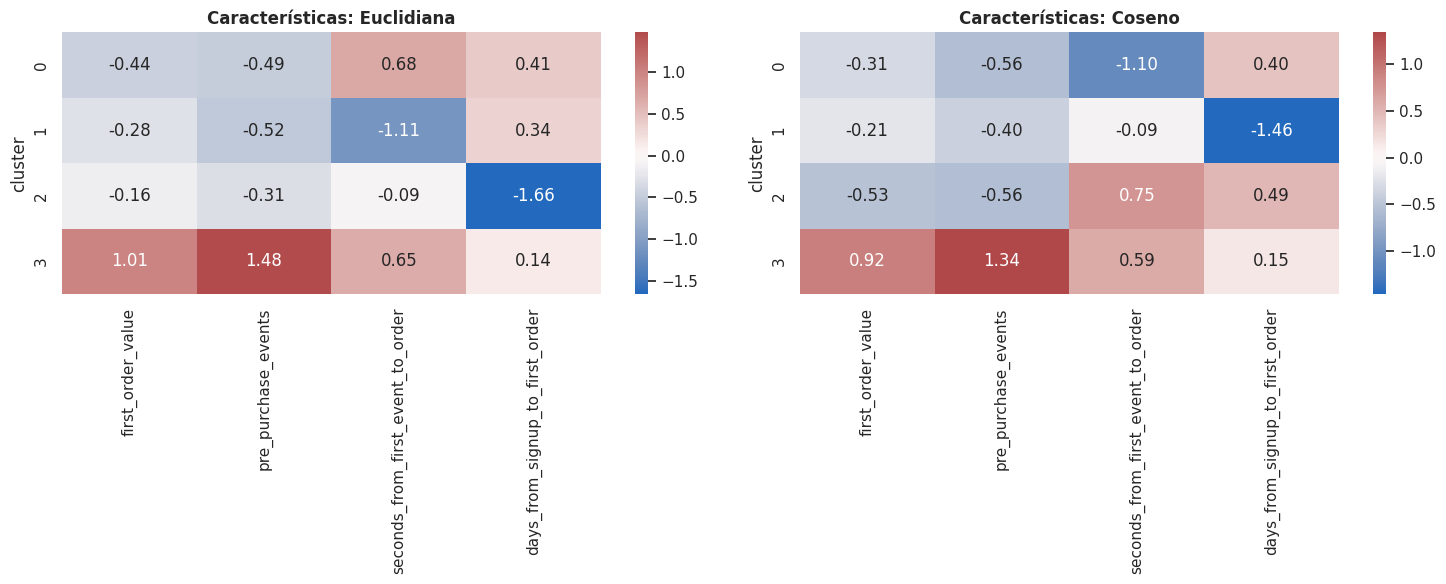

In [ ]:
euclidean_characteristics = (
    cluster_scaled
    .assign(
        cluster=feature_df[
            "cluster_euclidean"
        ]
    )
    .groupby("cluster")
    .mean()
)

cosine_characteristics = (
    cluster_scaled
    .assign(
        cluster=feature_df[
            "cluster_cosine"
        ]
    )
    .groupby("cluster")
    .mean()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.heatmap(
    euclidean_characteristics,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag",
    ax=axes[0]
)

axes[0].set_title(
    "Características: Euclidiana"
)

sns.heatmap(
    cosine_characteristics,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag",
    ax=axes[1]
)

axes[1].set_title(
    "Características: Coseno"
)

plt.tight_layout()
plt.show()

## 23. Variables categóricas por arquetipo

Las variables categóricas no determinaron la distancia. Se utilizan para conocer la composición de cada arquetipo.

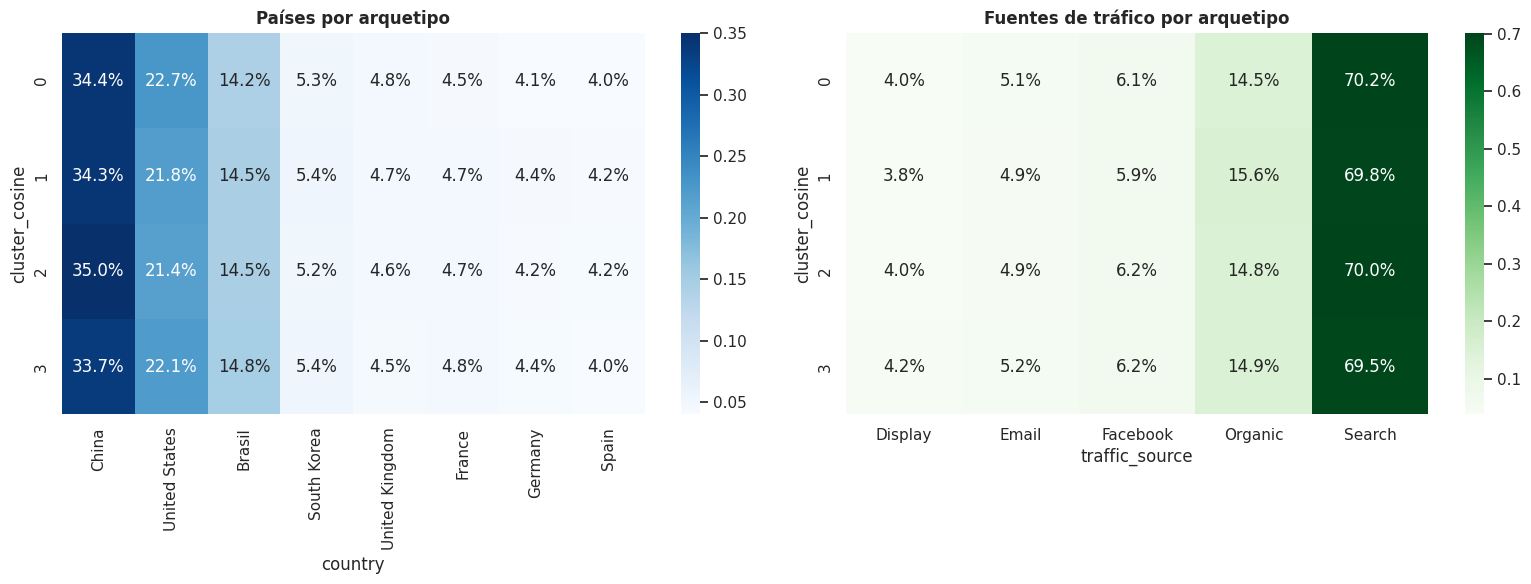

In [ ]:
selected_cluster_column = (
    "cluster_cosine"
)
top_countries = (
    feature_df["country"]
    .value_counts()
    .head(8)
    .index
)

country_composition = pd.crosstab(
    feature_df[selected_cluster_column],
    feature_df["country"],
    normalize="index"
)

country_composition = country_composition[
    [
        country
        for country in top_countries
        if country
        in country_composition.columns
    ]
]

traffic_composition = pd.crosstab(
    feature_df[selected_cluster_column],
    feature_df["traffic_source"],
    normalize="index"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.heatmap(
    country_composition,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title(
    "Países por arquetipo"
)

sns.heatmap(
    traffic_composition,
    annot=True,
    fmt=".1%",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title(
    "Fuentes de tráfico por arquetipo"
)

plt.tight_layout()
plt.show()

In [ ]:
selected_profile = (
    euclidean_profile.copy()
    if selected_cluster_column
    == "cluster_euclidean"
    else cosine_profile.copy()
)

general_medians = feature_df[
    [
        "first_order_value",
        "pre_purchase_events",
        "seconds_from_first_event_to_order"
    ]
].median()


def generate_archetype(row):
    if (
        row["first_order_value"]
        >= general_medians["first_order_value"]
    ):
        value = "Compra alta"
    else:
        value = "Compra baja"

    if (
        row["pre_purchase_events"]
        >= general_medians["pre_purchase_events"]
    ):
        navigation = "explorador"
    else:
        navigation = "directo"

    if (
        row["seconds_to_order"]
        <= general_medians[
            "seconds_from_first_event_to_order"
        ]
    ):
        decision = "rápido"
    else:
        decision = "deliberado"

    return f"{value}, {navigation} y {decision}"


selected_profile["archetype"] = (
    selected_profile.apply(
        generate_archetype,
        axis=1
    )
)

display(
    selected_profile[
        [
            selected_cluster_column,
            "archetype",
            "customers",
            "customer_share",
            "repeat_rate"
        ]
    ].style.format({
        "customers": "{:,.0f}",
        "customer_share": "{:.2%}",
        "repeat_rate": "{:.2%}"
    })
)

,cluster_cosine,archetype,customers,customer_share,repeat_rate
0,0,"Compra baja, explorador y rápido","20,523",29.58%,6.32%
1,1,"Compra baja, explorador y rápido","13,060",18.82%,15.25%
2,2,"Compra baja, explorador y deliberado","16,470",23.73%,6.17%
3,3,"Compra alta, explorador y deliberado","19,340",27.87%,7.48%


In [ ]:
cosine_archetype_names = {
    0: "Comprador directo y rápido",
    1: "Cliente de activación temprana",
    2: "Cliente de maduración larga y compra deliberada",
    3: "Explorador de alto valor"
}

feature_df["archetype_cosine"] = (
    feature_df["cluster_cosine"]
    .map(cosine_archetype_names)
)
corrected_archetype_summary = (
    feature_df
    .groupby(
        [
            "cluster_cosine",
            "archetype_cosine"
        ]
    )
    .agg(
        customers=("user_id", "nunique"),
        first_order_value=(
            "first_order_value",
            "median"
        ),
        pre_purchase_events=(
            "pre_purchase_events",
            "median"
        ),
        seconds_to_order=(
            "seconds_from_first_event_to_order",
            "median"
        ),
        signup_to_order_days=(
            "days_from_signup_to_first_order",
            "median"
        ),
        repeat_rate=(
            "label_repeat_purchase_90d",
            "mean"
        )
    )
    .reset_index()
)

corrected_archetype_summary[
    "customer_share"
] = (
    corrected_archetype_summary["customers"]
    / corrected_archetype_summary["customers"].sum()
)

display(
    corrected_archetype_summary.style.format({
        "customers": "{:,.0f}",
        "first_order_value": "${:,.2f}",
        "repeat_rate": "{:.2%}",
        "customer_share": "{:.2%}"
    })
)

,cluster_cosine,archetype_cosine,customers,first_order_value,pre_purchase_events,seconds_to_order,signup_to_order_days,repeat_rate,customer_share
0,0,Comprador directo y rápido,"20,523",$41.99,4.000000,3407.000000,603.000000,6.32%,29.58%
1,1,Cliente de activación temprana,"13,060",$46.99,4.000000,7763.000000,59.000000,15.25%,18.82%
2,2,Cliente de maduración larga y compra deliberada,"16,470",$34.99,4.000000,11280.500000,673.000000,6.17%,23.73%
3,3,Explorador de alto valor,"19,340",$132.36,12.000000,11064.500000,480.500000,7.48%,27.87%


0. Comprador rápido, pero poco recurrente
- Es el grupo más grande: representa 29.58% de los clientes.
- Cuando decide comprar, completa su compra rápidamente, en aproximadamente 57 minutos.
- Su primera compra típica es de $41.99.
- Solo 6.32% vuelve a comprar dentro de 90 días.

Nota: Son clientes que compran rápido y sin explorar demasiado, pero normalmente no regresan. La oportunidad está en contactarlos inmediatamente después de su primera compra para motivar una segunda orden.

1. Cliente nuevo con alta recompra
- Representa 18.82% de los clientes.
- Hace su primera compra aproximadamente 59 días después de registrarse.
- Su primera compra típica es de $46.99.
- Tiene la recompra más alta: 15.25%.

Nota: Son clientes que empiezan a comprar poco tiempo después de registrarse y tienen muchas más posibilidades de regresar. Este es el grupo más atractivo para una estrategia de retención. Tal vez crearon la cuenta porque tenian en mente comprar algo y su meta es seguir comprando.

La acción sería facilitar que los usuarios nuevos hagan pronto su primera compra mediante:
descuentos de bienvenida,
recordatorios,
recomendaciones,
promociones para la primera orden.

2. Cliente que tarda en comprar y no suele regresar
- Representa 23.73% de los clientes.
- Tarda alrededor de 3 horas y 8 minutos durante su proceso de compra.
- Su primera compra ocurre aproximadamente 673 días después de registrarse.
- Tiene el ticket más bajo: $34.99.
- Presenta la recompra más baja: 6.17%.

Nota: Son clientes que tardan mucho en realizar su primera compra y, después de comprar, normalmente no regresan. Podrían estar encontrando obstáculos, poca urgencia o poco valor en la experiencia.

La acción sería probar:
promociones con vigencia limitada;
recordatorios de carrito;
simplificación del proceso de compra;
campañas de reactivación.

3. Comprador de alto valor
- Representa 27.87% de los clientes.
- Su primera orden típica es de $132.36, la más alta.
- Realiza aproximadamente 12 eventos antes de comprar, por lo que revisa más opciones.
- Su recompra es de 7.48%, menor al promedio general de 8.29%.

Nota: Son clientes que investigan más y realizan compras iniciales de mayor valor, pero eso no significa que vayan a regresar. Conviene cuidarlos después de la primera compra porque tienen un mayor valor económico.

La acción sería ofrecerles:
recomendaciones premium;
productos complementarios;
beneficios por una segunda compra;
programas de lealtad.

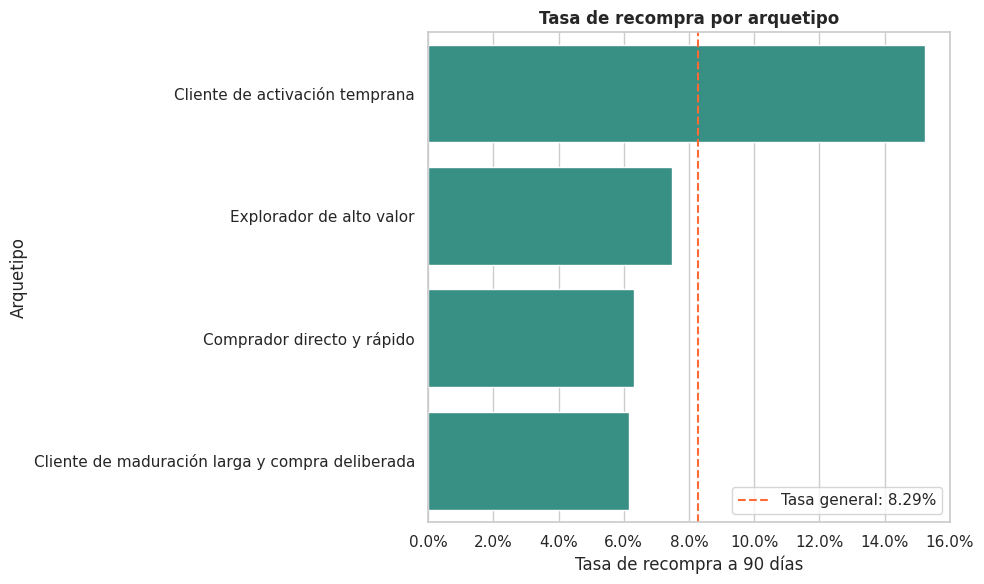

In [ ]:
overall_repeat_rate = (
    feature_df["label_repeat_purchase_90d"]
    .mean()
)

archetype_plot = corrected_archetype_summary.sort_values(
    "repeat_rate",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=archetype_plot,
    y="archetype_cosine",
    x="repeat_rate",
    color=COLORS[2]
)

plt.axvline(
    overall_repeat_rate,
    color=COLORS[0],
    linestyle="--",
    label=f"Tasa general: {overall_repeat_rate:.2%}"
)

plt.title("Tasa de recompra por arquetipo")
plt.xlabel("Tasa de recompra a 90 días")
plt.ylabel("Arquetipo")
plt.gca().xaxis.set_major_formatter(
    lambda value, _: f"{value:.1%}"
)
plt.legend()
plt.tight_layout()
plt.show()

## **Esto indica que conviene acelerar la primera compra y después aplicar estrategias distintas para cada tipo de cliente.**

In [ ]:
sql_first_order_status = f"""
SELECT
    features.user_id,
    features.first_order_id,
    COALESCE(orders.status, 'Unknown') AS first_order_status,

    IF(
        LOWER(TRIM(COALESCE(orders.status, ''))) IN (
            'cancelled',
            'canceled'
        ),
        1,
        0
    ) AS first_order_cancelled,

    IF(
        LOWER(TRIM(COALESCE(orders.status, ''))) = 'returned'
        OR orders.returned_at IS NOT NULL,
        1,
        0
    ) AS first_order_returned,

    IF(
        LOWER(TRIM(COALESCE(orders.status, ''))) IN (
            'cancelled',
            'canceled',
            'returned'
        )
        OR orders.returned_at IS NOT NULL,
        1,
        0
    ) AS first_order_problematic

FROM `{feature_table_id}` AS features

LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS orders
    ON features.first_order_id = orders.order_id
"""

first_order_status_df = (
    client.query(sql_first_order_status)
    .to_dataframe()
    .drop_duplicates("user_id")
)

feature_df = feature_df.drop(
    columns=[
        "first_order_status",
        "first_order_cancelled",
        "first_order_returned",
        "first_order_problematic"
    ],
    errors="ignore"
)

feature_df = feature_df.merge(
    first_order_status_df,
    on=["user_id", "first_order_id"],
    how="left"
)

display(
    feature_df[
        [
            "user_id",
            "archetype_cosine",
            "first_order_status",
            "first_order_cancelled",
            "first_order_returned",
            "first_order_problematic"
        ]
    ].head()
)

,user_id,archetype_cosine,first_order_status,first_order_cancelled,first_order_returned,first_order_problematic
0,13252,Comprador directo y rápido,Complete,0,0,0
1,80181,Comprador directo y rápido,Cancelled,1,0,1
2,88058,Comprador directo y rápido,Shipped,0,0,0
3,77140,Explorador de alto valor,Complete,0,0,0
4,7740,Comprador directo y rápido,Cancelled,1,0,1


In [ ]:
cancellation_summary = (
    feature_df
    .groupby("archetype_cosine")
    .agg(
        customers=("user_id", "nunique"),
        cancellation_rate=(
            "first_order_cancelled",
            "mean"
        ),
        return_rate=(
            "first_order_returned",
            "mean"
        ),
        repeat_rate=(
            "label_repeat_purchase_90d",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)

display(
    cancellation_summary.style.format({
        "customers": "{:,.0f}",
        "cancellation_rate": "{:.2%}",
        "return_rate": "{:.2%}",
        "repeat_rate": "{:.2%}"
    })
)

,archetype_cosine,customers,cancellation_rate,return_rate,repeat_rate
1,Cliente de maduración larga y compra deliberada,"16,470",15.42%,9.93%,6.17%
0,Cliente de activación temprana,"13,060",15.41%,10.90%,15.25%
2,Comprador directo y rápido,"20,523",14.85%,9.78%,6.32%
3,Explorador de alto valor,"19,340",14.79%,9.93%,7.48%


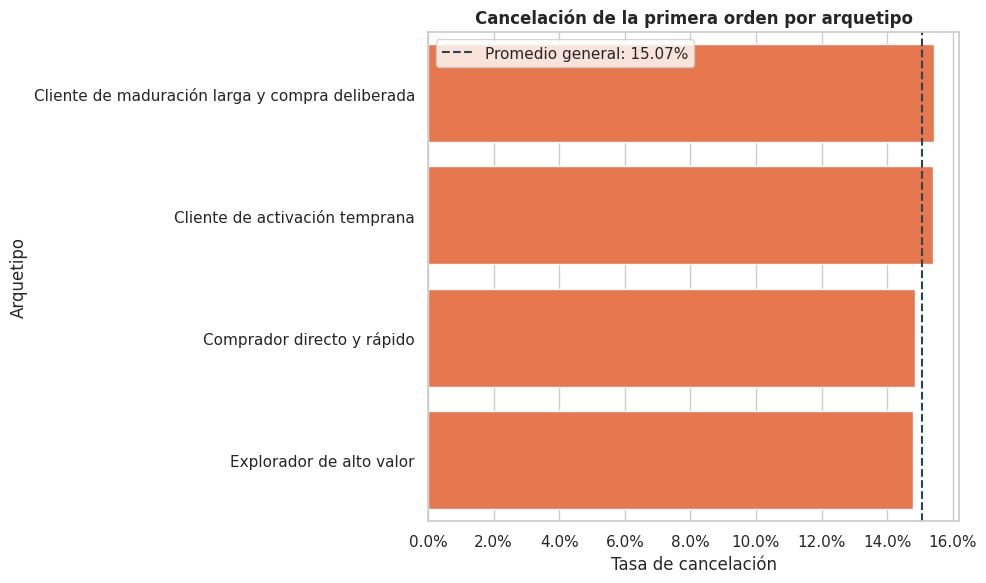

In [ ]:
overall_cancellation_rate = (
    feature_df["first_order_cancelled"]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cancellation_summary,
    y="archetype_cosine",
    x="cancellation_rate",
    color=COLORS[0]
)

plt.axvline(
    overall_cancellation_rate,
    color=COLORS[1],
    linestyle="--",
    label=(
        f"Promedio general: "
        f"{overall_cancellation_rate:.2%}"
    )
)

plt.title(
    "Cancelación de la primera orden por arquetipo"
)
plt.xlabel("Tasa de cancelación")
plt.ylabel("Arquetipo")
plt.gca().xaxis.set_major_formatter(
    lambda value, _: f"{value:.1%}"
)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
cancellation_repeat_relationship = (
    feature_df
    .groupby("first_order_cancelled")
    .agg(
        customers=("user_id", "nunique"),
        repeat_rate=(
            "label_repeat_purchase_90d",
            "mean"
        )
    )
    .reset_index()
)

cancellation_repeat_relationship[
    "first_order_result"
] = cancellation_repeat_relationship[
    "first_order_cancelled"
].map({
    0: "No canceló",
    1: "Canceló"
})

display(
    cancellation_repeat_relationship.style.format({
        "customers": "{:,.0f}",
        "repeat_rate": "{:.2%}"
    })
)

,first_order_cancelled,customers,repeat_rate,first_order_result
0,0,"58,933",8.26%,No canceló
1,1,"10,460",8.42%,Canceló
